# **Proyek Penambangan Data**

**Graph-Based Movie Recommendation System dengan Analisis Kemiripan Pengguna pada Dataset MovieLens**


**Kelompok 4**

Anggota:

*   Jeika Antama Syalom Tarigan (24031554011)
*   Alifiyanti Putri Nur Azizah (24031554032)
*   Grace Pinkkan Ladyna (24031554137)
*   Astrid Septya Regita Pramesty (24031554171)

Kelas: 2024 B

Link Dataset: [MovieLens 100K](https://grouplens.org/datasets/movielens/100k/)

# **Import Library**

In [ ]:
# !pip install python-louvain networkx matplotlib seaborn -q

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx
from community import community_louvain
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import csr_matrix
from matplotlib.patches import Patch
import warnings
warnings.filterwarnings('ignore')

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


# **Load Dataset**

In [ ]:
# Load dataset movie
movies = pd.read_csv(
    "/content/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

# Load dataset rating
ratings = pd.read_csv(
    "/content/u.data",
    sep="\t",
    names=[
        "user_id",
        "item_id",
        "rating",
        "timestamp"
    ]
)

# Menampilkan 5 data awal
display(movies.head())
display(ratings.head())

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


Tabel tersebut merupakan tampilan awal dataset u.item dari MovieLens sebelum dilakukan preprocessing. Dataset ini berisi informasi mengenai film beserta genre yang dimiliki setiap film.

Penjelasan kolom:

*   Kolom 0 → item_id, yaitu ID unik film.
*   Kolom 1 → judul film (title).
*   Kolom 2 → tanggal rilis film.
*   Kolom 3 → video release date (banyak bernilai kosong/NaN).
*   Kolom 4 → link IMDb film.
*   Kolom 5–23 → atribut genre film dalam bentuk biner (0 dan 1).

Urutan genre pada kolom 5–23 sudah ditetapkan oleh dataset MovieLens, yaitu:
unknown, Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, Musical, Mystery, Romance, Sci-Fi, Thriller, War, dan Western.

Nilai pada kolom genre memiliki arti:

*   1 = film termasuk genre tersebut.
*   0 = film tidak termasuk genre tersebut.


# **Eksplorasi Awal Data**

## Informasi Dataset

Bagian ini digunakan untuk mengetahui jumlah total interaksi rating, jumlah pengguna, dan jumlah film pada dataset MovieLens 100K sebelum dilakukan preprocessing.

In [ ]:
print("Jumlah rating:",
      ratings.shape[0])

print("Jumlah user:",
      ratings["user_id"].nunique())

print("Jumlah movie:",
      ratings["item_id"].nunique())

Jumlah rating: 100000
Jumlah user: 943
Jumlah movie: 1682


## Distribusi Rating

Tahap ini bertujuan untuk melihat distribusi nilai rating yang diberikan pengguna, sehingga dapat diketahui apakah pengguna cenderung memberikan rating tinggi atau rendah.

In [ ]:
print(ratings["rating"].value_counts())

rating
4    34174
3    27145
5    21201
2    11370
1     6110
Name: count, dtype: int64


## Sparsity Awal Dataset

Sparsity digunakan untuk mengetahui tingkat kepadatan data rating. Nilai sparsity yang tinggi menunjukkan bahwa sebagian besar pengguna hanya memberikan rating pada sebagian kecil film dibandingkan seluruh kemungkinan interaksi user-item.

In [ ]:
n_users = ratings[
    "user_id"
].nunique()

n_items = ratings[
    "item_id"
].nunique()

sparsity = 1 - (
    len(ratings) /
    (n_users * n_items)
)

print("Sparsity Awal:",
      round(sparsity, 4))

Sparsity Awal: 0.937


## Bar Chart dan Pie Chart Distribusi Rating

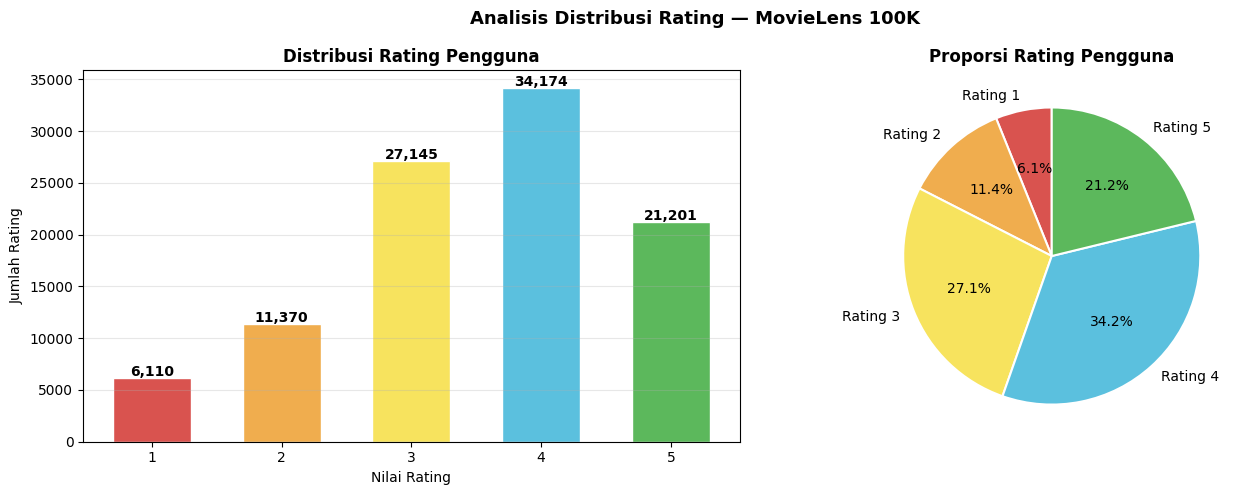


Rating paling banyak diberikan: Rating 4 (34,174 kali)
Rating paling jarang diberikan: Rating 1 (6,110 kali)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: bar chart distribusi rating
rating_counts = ratings['rating'].value_counts().sort_index()
colors_bar    = ['#d9534f','#f0ad4e','#f7e35e','#5bc0de','#5cb85c']

bars = axes[0].bar(
    rating_counts.index,
    rating_counts.values,
    color=colors_bar,
    edgecolor='white',
    width=0.6
)
axes[0].set_title(
    'Distribusi Rating Pengguna',
    fontweight='bold', fontsize=12
)
axes[0].set_xlabel('Nilai Rating')
axes[0].set_ylabel('Jumlah Rating')
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].grid(axis='y', alpha=0.3)

for bar, val in zip(bars, rating_counts.values):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 200,
        f'{val:,}',
        ha='center', fontsize=10, fontweight='bold'
    )

# Kanan: pie chart proporsi rating
axes[1].pie(
    rating_counts.values,
    labels=[f'Rating {r}' for r in rating_counts.index],
    colors=colors_bar,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title(
    'Proporsi Rating Pengguna',
    fontweight='bold', fontsize=12
)

fig.suptitle(
    'Analisis Distribusi Rating — MovieLens 100K',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"\nRating paling banyak diberikan: "
      f"Rating {rating_counts.idxmax()} "
      f"({rating_counts.max():,} kali)")
print(f"Rating paling jarang diberikan: "
      f"Rating {rating_counts.idxmin()} "
      f"({rating_counts.min():,} kali)")

## Histogram Rating per User & Film

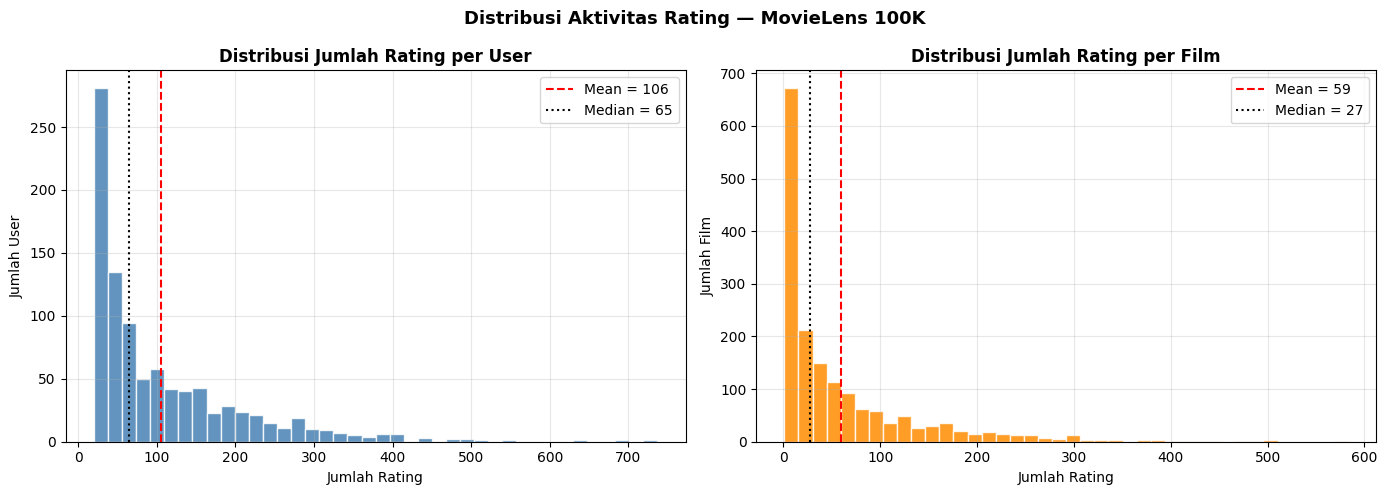


Statistik Rating per User:
   Min    : 20
   Max    : 737
   Mean   : 106.0
   Median : 65

Statistik Rating per Film:
   Min    : 1
   Max    : 583
   Mean   : 59.5
   Median : 27


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Hitung jumlah rating per user dan per film
user_rating_count  = ratings.groupby('user_id')['rating'].count()
movie_rating_count = ratings.groupby('item_id')['rating'].count()

# Kiri: histogram rating per user
axes[0].hist(
    user_rating_count,
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)
axes[0].axvline(
    user_rating_count.mean(),
    color='red', linestyle='--', linewidth=1.5,
    label=f'Mean = {user_rating_count.mean():.0f}'
)
axes[0].axvline(
    user_rating_count.median(),
    color='black', linestyle=':', linewidth=1.5,
    label=f'Median = {user_rating_count.median():.0f}'
)
axes[0].set_title(
    'Distribusi Jumlah Rating per User',
    fontweight='bold', fontsize=12
)
axes[0].set_xlabel('Jumlah Rating')
axes[0].set_ylabel('Jumlah User')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Kanan: histogram rating per film
axes[1].hist(
    movie_rating_count,
    bins=40,
    color='darkorange',
    edgecolor='white',
    alpha=0.85
)
axes[1].axvline(
    movie_rating_count.mean(),
    color='red', linestyle='--', linewidth=1.5,
    label=f'Mean = {movie_rating_count.mean():.0f}'
)
axes[1].axvline(
    movie_rating_count.median(),
    color='black', linestyle=':', linewidth=1.5,
    label=f'Median = {movie_rating_count.median():.0f}'
)
axes[1].set_title(
    'Distribusi Jumlah Rating per Film',
    fontweight='bold', fontsize=12
)
axes[1].set_xlabel('Jumlah Rating')
axes[1].set_ylabel('Jumlah Film')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle(
    'Distribusi Aktivitas Rating — MovieLens 100K',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"\nStatistik Rating per User:")
print(f"   Min    : {user_rating_count.min()}")
print(f"   Max    : {user_rating_count.max()}")
print(f"   Mean   : {user_rating_count.mean():.1f}")
print(f"   Median : {user_rating_count.median():.0f}")

print(f"\nStatistik Rating per Film:")
print(f"   Min    : {movie_rating_count.min()}")
print(f"   Max    : {movie_rating_count.max()}")
print(f"   Mean   : {movie_rating_count.mean():.1f}")
print(f"   Median : {movie_rating_count.median():.0f}")

## Top 10 Genre & Top 10 Film

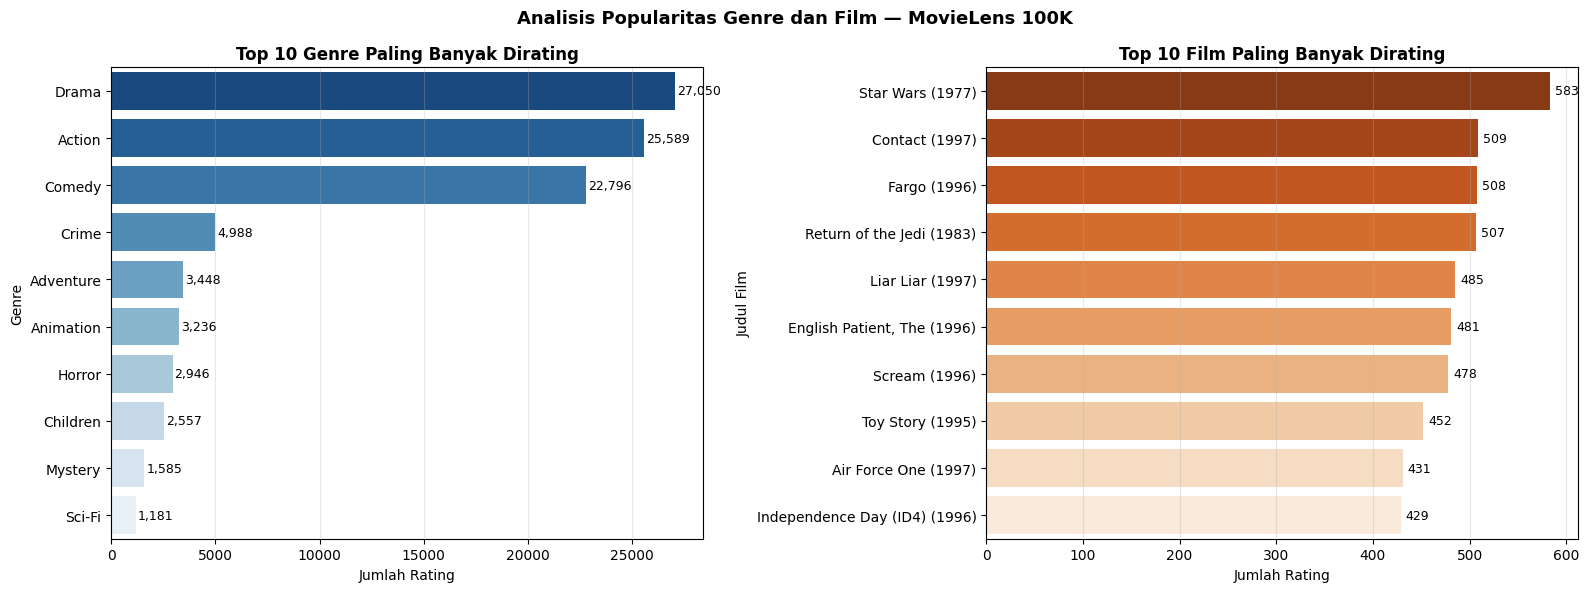

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Start of added preprocessing steps for 'movies' DataFrame ---
# These steps are replicated from earlier cells to ensure the 'movies' DataFrame has the necessary columns.

# ambil kolom genre 5–23
genre_cols = list(range(5,24))

# pilih kolom
movies = movies[[0,1] + genre_cols]

genre_names = [
    "unknown","Action","Adventure","Animation",
    "Children","Comedy","Crime","Documentary",
    "Drama","Fantasy","Film-Noir","Horror",
    "Musical","Mystery","Romance","Sci-Fi",
    "Thriller","War","Western"
]

movies.columns = ["item_id","title"] + genre_names

movies["main_genre"] = movies[
    genre_names
].idxmax(axis=1)
# --- End of added preprocessing steps for 'movies' DataFrame ---

# Kiri: top 10 genre paling populer
# Gabungkan ratings dengan movies untuk dapat info genre
ratings_genre = ratings.merge(
    movies[['item_id', 'main_genre']],
    on='item_id',
    how='left'
)
genre_counts = (
    ratings_genre['main_genre']
    .value_counts()
    .head(10)
)

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    palette='Blues_r',
    ax=axes[0]
)
axes[0].set_title(
    'Top 10 Genre Paling Banyak Dirating',
    fontweight='bold', fontsize=12
)
axes[0].set_xlabel('Jumlah Rating')
axes[0].set_ylabel('Genre')
axes[0].grid(axis='x', alpha=0.3)

for i, val in enumerate(genre_counts.values):
    axes[0].text(
        val + 100, i,
        f'{val:,}',
        va='center', fontsize=9
    )

# Kanan: top 10 film paling banyak dirating
top_movies = (
    ratings.groupby('item_id')['rating']
    .count()
    .reset_index()
    .rename(columns={'rating': 'jumlah_rating'})
    .merge(movies[['item_id', 'title']], on='item_id')
    .sort_values('jumlah_rating', ascending=False)
    .head(10)
)

sns.barplot(
    x='jumlah_rating',
    y='title',
    data=top_movies,
    palette='Oranges_r',
    ax=axes[1]
)
axes[1].set_title(
    'Top 10 Film Paling Banyak Dirating',
    fontweight='bold', fontsize=12
)
axes[1].set_xlabel('Jumlah Rating')
axes[1].set_ylabel('Judul Film')
axes[1].grid(axis='x', alpha=0.3)

for i, val in enumerate(top_movies['jumlah_rating'].values):
    axes[1].text(
        val + 5, i,
        str(val),
        va='center', fontsize=9
    )

fig.suptitle(
    'Analisis Popularitas Genre dan Film — MovieLens 100K',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

# **Preprocessing Data**

Menyiapkan informasi film yang akan digunakan dalam interpretasi hasil rekomendasi, analisis komunitas pengguna, dan identifikasi genre film dominan pada setiap komunitas.

# **Preprocessing u.item**

## Tampilan Awal Dataset Film

In [ ]:
movies.head()

,item_id,title,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,main_genre
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,Animation
1,2,GoldenEye (1995),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Action
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Thriller
3,4,Get Shorty (1995),0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Action
4,5,Copycat (1995),0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,Crime


Tabel tersebut merupakan tampilan awal dataset u.item dari MovieLens sebelum dilakukan preprocessing. Dataset ini berisi informasi mengenai film beserta genre yang dimiliki setiap film.

Penjelasan kolom:

*   Kolom 0 → item_id, yaitu ID unik film.
*   Kolom 1 → judul film (title).
*   Kolom 2 → tanggal rilis film.
*   Kolom 3 → video release date (banyak bernilai kosong/NaN).
*   Kolom 4 → link IMDb film.
*   Kolom 5–23 → atribut genre film dalam bentuk biner (0 dan 1).

Urutan genre pada kolom 5–23 sudah ditetapkan oleh dataset MovieLens, yaitu:
unknown, Action, Adventure, Animation, Children, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, Musical, Mystery, Romance, Sci-Fi, Thriller, War, dan Western.

Nilai pada kolom genre memiliki arti:

*   1 = film termasuk genre tersebut.
*   0 = film tidak termasuk genre tersebut.


## Memilih Atribut yang Relevan

Dataset film memiliki banyak atribut, namun penelitian ini menggunakan:

*   item_id
*   title
*   atribut genre film

Atribut genre digunakan untuk analisis karakteristik komunitas pengguna berdasarkan preferensi genre film.

In [ ]:
movies = pd.read_csv(
    "/content/u.item",
    sep="|",
    encoding="latin-1",
    header=None
)

# ambil kolom genre 5–23
genre_cols = list(range(5,24))

# pilih kolom
movies = movies[[0,1] + genre_cols]

# cek jumlah kolom
print(movies.shape)

(1682, 21)


## Rename Kolom

In [ ]:
genre_names = [
    "unknown","Action","Adventure","Animation",
    "Children","Comedy","Crime","Documentary",
    "Drama","Fantasy","Film-Noir","Horror",
    "Musical","Mystery","Romance","Sci-Fi",
    "Thriller","War","Western"
]

movies.columns = ["item_id","title"] + genre_names

display(movies.head())

,item_id,title,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Fantasy,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0


## Pengecekan Missing Value

Dilakukan pengecekan untuk memastikan tidak terdapat data kosong.

In [ ]:
print("Missing value:\n",
      movies.isnull().sum())

Missing value:
 item_id        0
title          0
unknown        0
Action         0
Adventure      0
Animation      0
Children       0
Comedy         0
Crime          0
Documentary    0
Drama          0
Fantasy        0
Film-Noir      0
Horror         0
Musical        0
Mystery        0
Romance        0
Sci-Fi         0
Thriller       0
War            0
Western        0
dtype: int64


## Penghapusan Duplikasi

Menghapus kemungkinan data film yang duplikat berdasarkan item_id.



In [ ]:
before = movies.shape[0]

movies = movies.drop_duplicates(
    subset=["item_id"]
)

after = movies.shape[0]

print("Jumlah data sebelum:", before)
print("Jumlah data sesudah:", after)
print("Jumlah duplikasi yang dihapus:",
      before - after)

Jumlah data sebelum: 1682
Jumlah data sesudah: 1682
Jumlah duplikasi yang dihapus: 0


## Membersihkan Judul Film

Membersihkan teks judul film dari spasi berlebih dan tahun rilis.


In [ ]:
movies["title"] = movies[
    "title"
].str.strip()

movies["title"] = movies[
    "title"
].str.replace(
    r"\(\d{4}\)",
    "",
    regex=True
)

## Menentukan Genre Utama Film

Fungsi idxmax() digunakan untuk mencari genre dengan nilai tertinggi atau bernilai 1 pada setiap film. Genre utama digunakan untuk analisis karakteristik komunitas pengguna.

In [ ]:
movies["main_genre"] = movies[
    genre_names
].idxmax(axis=1)

## Reset Index

Mengatur ulang index dataset setelah proses cleaning.

In [ ]:
movies = movies.reset_index(
    drop=True
)

display(movies.head())

,item_id,title,unknown,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,main_genre
0,1,Toy Story,0,0,0,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,Animation
1,2,GoldenEye,0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Action
2,3,Four Rooms,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,Thriller
3,4,Get Shorty,0,1,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,Action
4,5,Copycat,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,Crime


# **Preprocessing u.data**

Menyiapkan data rating pengguna agar siap digunakan dalam proses similarity computation, graph construction, community detection, dan recommendation system.

## **a. Data Cleaning**

pengecekan missing value

penghapusan duplikasi user-item

validasi rating 1–5

### Tampilan Awal Dataset Rating

In [ ]:
display(ratings.head())

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


### Pengecekan Missing Value

In [ ]:
print("Missing value:\n",
      ratings.isnull().sum())

Missing value:
 user_id      0
item_id      0
rating       0
timestamp    0
dtype: int64


### Penghapusan Duplikasi User-Item

satu user hanya boleh memiliki satu rating untuk satu film

In [ ]:
before = ratings.shape[0]

ratings = ratings.drop_duplicates(
    subset=["user_id", "item_id"]
)

after = ratings.shape[0]

print("Jumlah data sebelum:", before)
print("Jumlah data sesudah:", after)
print("Jumlah duplikasi yang dihapus:",
      before - after)

Jumlah data sebelum: 100000
Jumlah data sesudah: 100000
Jumlah duplikasi yang dihapus: 0


### Validasi Rating

Memastikan nilai rating berada pada rentang 1–5.



In [ ]:
ratings = ratings[
    (ratings["rating"] >= 1) &
    (ratings["rating"] <= 5)
]

print("Jumlah data setelah validasi:",
      ratings.shape)

Jumlah data setelah validasi: (100000, 4)


## **b. Data Filtering**

Mengurangi noise dan sparsity agar similarity antar pengguna lebih valid.

### Filtering User

Hanya pengguna dengan minimal 20 rating yang digunakan. User dengan terlalu sedikit rating sulit digunakan untuk menghitung similarity secara stabil.

In [ ]:
user_counts = ratings[
    "user_id"
].value_counts()

valid_users = user_counts[
    user_counts >= 20
].index

ratings = ratings[
    ratings["user_id"].isin(valid_users)
]

print("Jumlah user valid:",
      len(valid_users))

print("Shape data setelah filtering user:",
      ratings.shape)

Jumlah user valid: 943
Shape data setelah filtering user: (100000, 4)


### Filtering Movie

Hanya film dengan minimal 20 interaksi pengguna yang digunakan untuk mengurangi sparsity dan noise pada dataset.

In [ ]:
movie_counts = ratings[
    "item_id"
].value_counts()

valid_movies = movie_counts[
    movie_counts >= 20
].index

ratings = ratings[
    ratings["item_id"].isin(valid_movies)
]

print("Jumlah film valid:",
      len(valid_movies))

print("Shape data setelah filtering movie:",
      ratings.shape)

Jumlah film valid: 939
Shape data setelah filtering movie: (94968, 4)


### Analisis Sparsity

Mengetahui tingkat kepadatan data rating setelah proses filtering.

In [ ]:
n_users = ratings[
    "user_id"
].nunique()

n_items = ratings[
    "item_id"
].nunique()

sparsity = 1 - (
    len(ratings) /
    (n_users * n_items)
)

print("Jumlah user:", n_users)
print("Jumlah movie:", n_items)
print("Sparsity:",
      round(sparsity, 4))

Jumlah user: 943
Jumlah movie: 939
Sparsity: 0.8927


Nilai sparsity awal sebesar 0,937 menunjukkan bahwa sebagian besar pasangan user-item tidak memiliki interaksi rating. Kondisi ini umum terjadi pada sistem rekomendasi dan menyebabkan data menjadi sangat sparse. Setelah dilakukan filtering film dengan minimal 20 interaksi, sparsity menurun menjadi 0,8927. Penurunan ini menunjukkan bahwa preprocessing berhasil meningkatkan kepadatan data sehingga hubungan antar pengguna dapat dihitung dengan lebih stabil pada proses similarity computation.

### Normalisasi Rating

Mengurangi bias penilaian antar pengguna menggunakan metode mean-centering.
Mean-centering digunakan karena setiap pengguna memiliki kecenderungan penilaian yang berbeda. Beberapa pengguna cenderung memberikan rating tinggi untuk hampir semua film, sedangkan pengguna lain lebih ketat dalam memberikan penilaian. Dengan mean-centering, proses similarity lebih berfokus pada pola preferensi relatif pengguna dibandingkan nilai rating absolut


In [ ]:
#Mean-Centering
user_mean = ratings.groupby(
    "user_id"
)["rating"].mean()

ratings["user_mean"] = ratings[
    "user_id"
].map(user_mean)

ratings["rating_norm"] = (
    ratings["rating"] -
    ratings["user_mean"]
)

display(ratings.head())

,user_id,item_id,rating,timestamp,user_mean,rating_norm
0,196,242,3,881250949,3.631579,-0.631579
1,186,302,3,891717742,3.481928,-0.481928
3,244,51,2,880606923,3.662338,-1.662338
4,166,346,1,886397596,3.526316,-2.526316
5,298,474,4,884182806,4.039683,-0.039683


### Feature Engineering

Membentuk fitur tambahan untuk analisis karakteristik pengguna.

1. user_mean → rata-rata rating user
2. user_var → variasi rating user
3. user_count → jumlah rating user

In [ ]:
# Membentuk Fitur Pengguna
user_var = ratings.groupby(
    "user_id"
)["rating"].var()

user_count = ratings.groupby(
    "user_id"
)["rating"].count()

user_features = pd.DataFrame({
    "user_mean": user_mean,
    "user_var": user_var,
    "user_count": user_count
})

display(user_features.head())

,user_mean,user_var,user_count
user_id,,,
1,3.675889,1.465964,253
2,3.766667,0.961582,60
3,2.901961,1.370196,51
4,4.238095,0.890476,21
5,2.974843,1.758857,159


In [ ]:
print("\n=== Ringkasan Preprocessing ===")

print("Jumlah User Awal  :", 943)
print("Jumlah Movie Awal :", 1682)
print("Jumlah Rating Awal:", 100000)

print("\nJumlah User Akhir :", ratings['user_id'].nunique())
print("Jumlah Movie Akhir:", ratings['item_id'].nunique())
print("Jumlah Rating Akhir:", ratings.shape[0])


=== Ringkasan Preprocessing ===
Jumlah User Awal  : 943
Jumlah Movie Awal : 1682
Jumlah Rating Awal: 100000

Jumlah User Akhir : 943
Jumlah Movie Akhir: 939
Jumlah Rating Akhir: 94968


# **Transformasi User-Item Matrix**

Mempersiapkan data untuk proses cosine similarity dan graph construction.

### Membentuk User-Item Matrix

In [ ]:
user_item_matrix = ratings.pivot_table(
    index="user_id",
    columns="item_id",
    values="rating_norm"
)

print("Shape User-Item Matrix:",
      user_item_matrix.shape)

display(user_item_matrix.head())

Shape User-Item Matrix: (943, 939)


item_id,1,2,3,4,5,6,7,8,9,10,...,1231,1240,1244,1258,1267,1284,1296,1315,1407,1411
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.324111,-0.675889,0.324111,-0.675889,-0.675889,1.324111,0.324111,-2.675889,1.324111,-0.675889,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.233333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.766667,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.025157,0.025157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Pada matrix ini, baris merepresentasikan pengguna (user) dan kolom merepresentasikan film (item). Nilai pada matrix merupakan rating hasil normalisasi menggunakan mean-centering.

### Handling Missing Value pada Matrix

Missing value diisi dengan 0 untuk menunjukkan bahwa pengguna belum memberikan rating terhadap film tertentu serta mempermudah proses perhitungan cosine similarity.

In [ ]:
user_item_matrix = (
    user_item_matrix.fillna(0)
)

print("Shape User-Item Matrix:",
      user_item_matrix.shape)

display(user_item_matrix.head())

Shape User-Item Matrix: (943, 939)


item_id,1,2,3,4,5,6,7,8,9,10,...,1231,1240,1244,1258,1267,1284,1296,1315,1407,1411
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.324111,-0.675889,0.324111,-0.675889,-0.675889,1.324111,0.324111,-2.675889,1.324111,-0.675889,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.233333,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.766667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,1.025157,0.025157,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# **Co-Rated Items**

Co-rated items digunakan untuk memastikan bahwa nilai similarity dihitung berdasarkan jumlah film bersama yang cukup. Dua pengguna dengan similarity tinggi tetapi hanya memiliki sedikit film yang sama dapat menghasilkan hubungan yang kurang stabil. Oleh karena itu, penelitian ini menerapkan minimal 5 co-rated items saat pembentukan graph untuk meningkatkan validitas hubungan antar pengguna.

### Menghitung Co-Rated Items


In [ ]:
binary_matrix = (
    user_item_matrix != 0
).astype(int)

co_rated_matrix = np.dot(
    binary_matrix,
    binary_matrix.T
)

co_rated_df = pd.DataFrame(
    co_rated_matrix,
    index=user_item_matrix.index,
    columns=user_item_matrix.index
)

display(co_rated_df.head())
print("Shape Co-Rated Matrix:",
      co_rated_df.shape)

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,253,18,8,7,79,96,145,34,5,77,...,77,15,48,19,36,15,52,10,27,83
2,18,60,9,7,5,32,18,6,6,16,...,15,14,33,20,24,11,17,7,12,9
3,8,9,51,13,1,10,13,6,2,8,...,3,2,16,6,10,2,15,4,9,2
4,7,7,13,21,2,6,12,8,2,4,...,3,1,8,6,7,1,10,4,8,4
5,79,5,1,2,159,42,100,23,4,35,...,58,6,15,5,21,6,28,6,17,59


Shape Co-Rated Matrix: (943, 943)


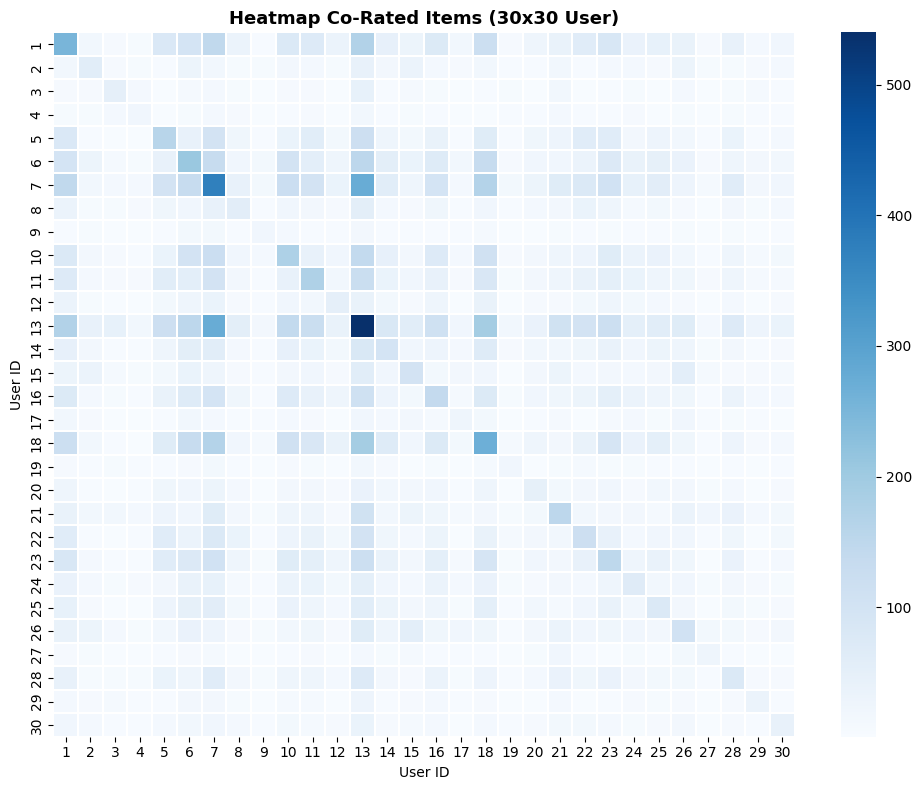

In [ ]:
# Ambil sebagian matrix agar visualisasi lebih jelas
sample_size = 30

sample_matrix = co_rated_df.iloc[
    :sample_size,
    :sample_size
]

plt.figure(figsize=(10,8))

sns.heatmap(
    sample_matrix,
    cmap='Blues',
    linewidths=0.3
)

plt.title(
    f'Heatmap Co-Rated Items ({sample_size}x{sample_size} User)',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('User ID')
plt.ylabel('User ID')

plt.tight_layout()
plt.show()

Warna yang semakin gelap menunjukkan jumlah film yang dinilai bersama semakin banyak, sedangkan warna terang menunjukkan interaksi bersama yang rendah. Sebagian besar pasangan pengguna memiliki jumlah co-rated items yang rendah. Hal tersebut menunjukkan bahwa dataset masih bersifat sparse karena setiap pengguna hanya memberikan rating pada sebagian kecil film yang tersedia. Namun, terdapat beberapa pasangan pengguna dengan jumlah co-rated items cukup tinggi yang menunjukkan adanya kesamaan interaksi film antar pengguna. Pada penelitian ini digunakan minimum co-rated items sebesar 5 untuk membentuk hubungan antar pengguna pada graph recommendation system agar similarity yang dihasilkan lebih valid dan representatif.


Dalam penelitian ini, kita menetapkan bahwa minimal 5 co-rated items sebagai syarat untuk membentuk koneksi antar dua pengguna di dalam graph.
Kenapa 5? Karena kalau terlalu kecil, similarity yang terhitung bisa tidak stabil dan menyesatkan. Dengan minimal 5 film yang sama, hubungan yang terbentuk lebih valid dan representatif.

# **Cosine Similarity**

Tahap ini bertujuan untuk mengukur tingkat kemiripan preferensi antar pengguna berdasarkan pola rating film yang diberikan. Metode yang digunakan adalah cosine similarity karena mampu mengukur kemiripan arah vektor rating antar user meskipun jumlah rating yang diberikan berbeda-beda.

In [ ]:
# Convert ke sparse matrix
matrix_sparse = csr_matrix(
    user_item_matrix.values
)

# Hitung cosine similarity
cos_sim_matrix = cosine_similarity(
    matrix_sparse
)

# Menghapus self-similarity (diagonal)
np.fill_diagonal(
    cos_sim_matrix,
    0
)

# Membentuk DataFrame similarity
user_ids = user_item_matrix.index.tolist()

similarity_df = pd.DataFrame(
    cos_sim_matrix,
    index=user_ids,
    columns=user_ids
)

print(
    f"Matriks similarity selesai: "
    f"{similarity_df.shape}"
)

print(
    "\nNilai similarity "
    "(5×5 user pertama):"
)

display(
    similarity_df.iloc[:5, :5].round(4)
)

Matriks similarity selesai: (943, 943)

Nilai similarity (5×5 user pertama):


,1,2,3,4,5
1,0.0000,0.0427,0.0163,0.0632,0.1513
2,0.0427,0.0000,0.0227,-0.0326,0.0357
3,0.0163,0.0227,0.0000,-0.0709,0.0161
4,0.0632,-0.0326,-0.0709,0.0000,0.0107
5,0.1513,0.0357,0.0161,0.0107,0.0000


Matriks cosine similarity berukuran (943, 943) menunjukkan tingkat kemiripan preferensi antar 943 pengguna berdasarkan pola rating film. Sebagian besar nilai similarity berada di sekitar nol, yang menunjukkan bahwa preferensi pengguna cukup beragam. Nilai positif menunjukkan preferensi yang mirip, seperti similarity 0.1513 antara user 1 dan user 5, sedangkan nilai negatif menunjukkan preferensi yang berlawanan, seperti -0.0709 antara user 3 dan user 4. Nilai diagonal bernilai 0.0000 karena self-similarity dihapus agar analisis hanya berfokus pada hubungan antar pengguna yang berbeda. Hasil ini menunjukkan bahwa diperlukan threshold similarity untuk menyaring hubungan pengguna yang benar-benar relevan pada tahap graph construction.

## Visualisasi Distribusi Cosine Similarity

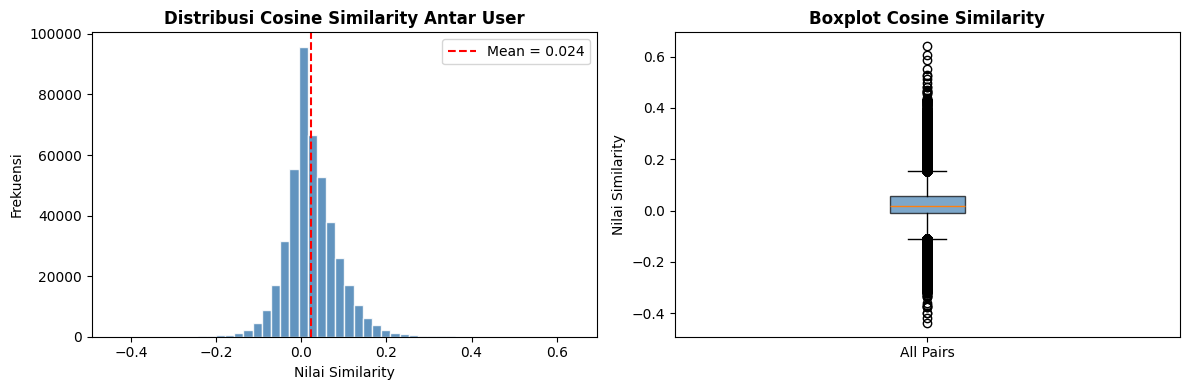

In [ ]:
# Mengambil upper triangle matrix
upper_tri = cos_sim_matrix[
    np.triu_indices_from(
        cos_sim_matrix,
        k=1
    )
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 4)
)

# Histogram similarity
axes[0].hist(
    upper_tri,
    bins=50,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

axes[0].set_title(
    'Distribusi Cosine Similarity Antar User',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('Nilai Similarity')
axes[0].set_ylabel('Frekuensi')

axes[0].axvline(
    np.mean(upper_tri),
    color='red',
    linestyle='--',
    label=f'Mean = {np.mean(upper_tri):.3f}'
)

axes[0].legend()

# Boxplot similarity
axes[1].boxplot(
    upper_tri,
    vert=True,
    patch_artist=True,
    boxprops=dict(
        facecolor='steelblue',
        alpha=0.7
    )
)

axes[1].set_title(
    'Boxplot Cosine Similarity',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_ylabel('Nilai Similarity')

axes[1].set_xticks([1])

axes[1].set_xticklabels(['All Pairs'])

plt.tight_layout()

plt.show()

Berdasarkan Gambar, sebagian besar nilai similarity berada di sekitar nol dengan rata-rata similarity sebesar 0,024. Hal tersebut menunjukkan bahwa mayoritas pengguna memiliki preferensi film yang berbeda-beda. Selain itu, terdapat beberapa pasangan pengguna dengan similarity tinggi yang menunjukkan adanya pengguna dengan pola preferensi yang mirip. Boxplot juga memperlihatkan bahwa sebagian besar nilai similarity terkonsentrasi di sekitar nol, meskipun terdapat beberapa outlier positif dan negatif. Kondisi ini menunjukkan bahwa hubungan antar pengguna cenderung sparse sehingga diperlukan threshold similarity untuk menyaring hubungan yang relevan pada proses graph construction.


## Statistik Cosine Similarity

In [ ]:
print(f"\nStatistik Cosine Similarity:")

print(
    f"   Min    : "
    f"{upper_tri.min():.4f}"
)

print(
    f"   Max    : "
    f"{upper_tri.max():.4f}"
)

print(
    f"   Mean   : "
    f"{upper_tri.mean():.4f}"
)

print(
    f"   Median : "
    f"{np.median(upper_tri):.4f}"
)

print(
    f"   Std    : "
    f"{upper_tri.std():.4f}"
)


Statistik Cosine Similarity:
   Min    : -0.4375
   Max    : 0.6408
   Mean   : 0.0239
   Median : 0.0165
   Std    : 0.0602


# **Threshold**

In [ ]:
thresholds     = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4]
threshold_info = []
n_users        = len(user_ids)

print(f"{'Threshold':>10} | {'Jumlah Edge':>12} | {'Density':>10} | {'Avg Degree':>12}")
print("-" * 52)

for t in thresholds:

    edge_count = 0

    for i in range(n_users):
        for j in range(i + 1, n_users):

            sim_val = cos_sim_matrix[i, j]
            corated = co_rated_matrix[i, j]

            if sim_val >= t and corated >= 5:
                edge_count += 1

    density    = (2 * edge_count) / (n_users * (n_users - 1)) if n_users > 1 else 0
    avg_degree = (2 * edge_count) / n_users if n_users > 0 else 0

    threshold_info.append({
        'threshold' : t,
        'n_edges'   : edge_count,
        'density'   : density,
        'avg_degree': avg_degree
    })

    print(f"{t:>10.2f} | {edge_count:>12,} | {density:>10.6f} | {avg_degree:>12.2f}")

threshold_df = pd.DataFrame(threshold_info)

 Threshold |  Jumlah Edge |    Density |   Avg Degree
----------------------------------------------------
      0.10 |       41,187 |   0.092732 |        87.35
      0.15 |       12,489 |   0.028119 |        26.49
      0.20 |        3,587 |   0.008076 |         7.61
      0.25 |        1,119 |   0.002519 |         2.37
      0.30 |          372 |   0.000838 |         0.79
      0.35 |          124 |   0.000279 |         0.26
      0.40 |           48 |   0.000108 |         0.10


In [ ]:
# Cek threshold tambahan
for t in [0.15, 0.25, 0.35]:
    n = int(np.sum(upper_tri >= t))
    print(f"Threshold {t}: {n:,} edge")

Threshold 0.15: 13,383 edge
Threshold 0.25: 1,214 edge
Threshold 0.35: 131 edge


Threshold 0.15 menghasilkan graph yang sangat padat dengan 12.489 edge sehingga hubungan antar pengguna menjadi terlalu luas dan komunitas yang terbentuk cenderung kurang spesifik. Sebaliknya, threshold 0.25 menghasilkan graph yang terlalu sparse dengan banyak komponen terpisah sehingga hubungan antar pengguna menjadi sangat terbatas. Oleh karena itu, threshold 0.20 dipilih karena menghasilkan keseimbangan antara jumlah edge, kepadatan graph, dan kualitas komunitas dengan modularity sebesar 0,5017.

## Visualisasi Pengaruh Threshold terhadap Struktur Graph

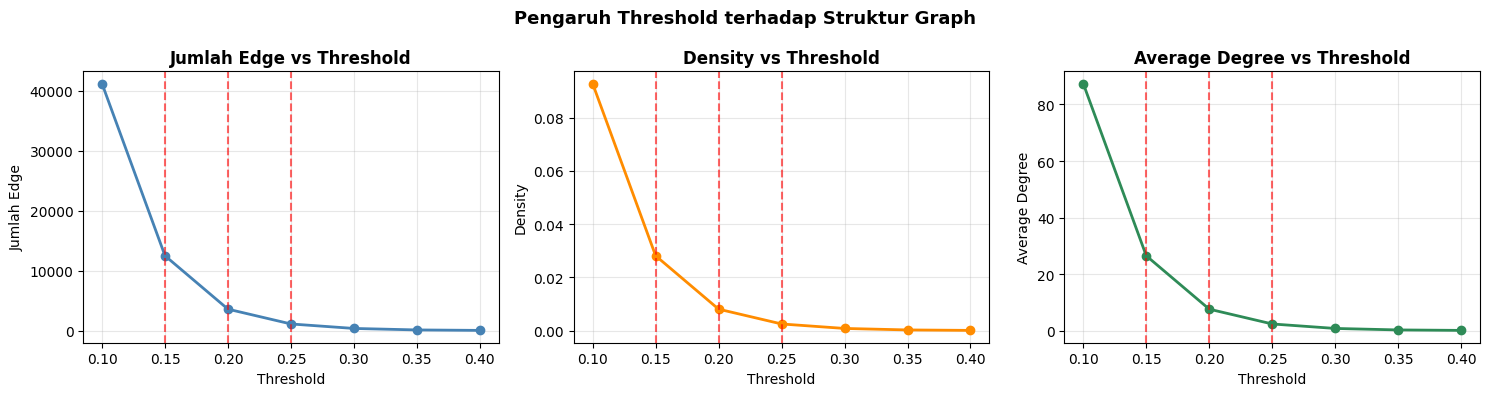

,threshold,n_edges,density,avg_degree
0,0.10,41187,0.092732,87.353128
1,0.15,12489,0.028119,26.487805
2,0.20,3587,0.008076,7.607635
3,0.25,1119,0.002519,2.373277
4,0.30,372,0.000838,0.788971
5,0.35,124,0.000279,0.262990
6,0.40,48,0.000108,0.101803


In [ ]:
thresholds_check = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40]

threshold_info = []

for t in thresholds_check:

    edge_count = 0

    for i in range(n_users):

        for j in range(i + 1, n_users):

            sim_val = cos_sim_matrix[i, j]
            corated = co_rated_matrix[i, j]

            if sim_val >= t and corated >= 5:

                edge_count += 1

    density = (
        2 * edge_count
    ) / (
        n_users * (n_users - 1)
    )

    avg_degree = (
        2 * edge_count
    ) / n_users

    threshold_info.append({
        'threshold'  : t,
        'n_edges'    : edge_count,
        'density'    : density,
        'avg_degree' : avg_degree
    })

threshold_df = pd.DataFrame(threshold_info)

# VISUALISASI

fig, axes = plt.subplots(1, 3, figsize=(15,4))

for ax, col, color, label in zip(
    axes,
    ['n_edges', 'density', 'avg_degree'],
    ['steelblue', 'darkorange', 'seagreen'],
    ['Jumlah Edge', 'Density', 'Average Degree']
):

    ax.plot(
        threshold_df['threshold'],
        threshold_df[col],
        marker='o',
        linewidth=2,
        color=color
    )

    ax.set_title(
        f'{label} vs Threshold',
        fontweight='bold'
    )

    ax.set_xlabel('Threshold')
    ax.set_ylabel(label)

    ax.grid(alpha=0.3)

    for t in [0.15, 0.20, 0.25]:
        ax.axvline(
            t,
            color='red',
            linestyle='--',
            alpha=0.6
        )

fig.suptitle(
    'Pengaruh Threshold terhadap Struktur Graph',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

display(threshold_df)

Seluruh metrik graph mengalami penurunan seiring meningkatnya threshold similarity. Penurunan paling terlihat terjadi pada jumlah edge dan average degree. Hal tersebut menunjukkan bahwa sebagian besar pasangan pengguna hanya memiliki similarity rendah sehingga akan tereliminasi ketika threshold dinaikkan. Selain itu, density graph juga semakin kecil yang menandakan hubungan antar pengguna menjadi lebih jarang. Garis merah pada grafik menunjukkan threshold eksperimen utama yaitu 0,15, 0,20, dan 0,25 yang digunakan pada tahap graph construction dan community detection.


# **Graph Construction**

## Build Graph

In [ ]:
def build_graph(sim_df, threshold, min_corated=5):

    G = nx.Graph()

    users = sim_df.index.tolist()

    G.add_nodes_from(users)

    n = len(users)

    for i in range(n):

        for j in range(i + 1, n):

            u1, u2 = users[i], users[j]

            sim_val = sim_df.iloc[i, j]

            # Mengambil jumlah co-rated items
            corated = co_rated_df.loc[u1, u2]

            # Membentuk edge jika memenuhi threshold
            if sim_val >= threshold and corated >= min_corated:

                G.add_edge(
                    u1,
                    u2,
                    weight=round(float(sim_val), 4)
                )

    return G

print("Fungsi build_graph() siap!")

Fungsi build_graph() siap!


In [ ]:
# Membentuk graph untuk beberapa threshold

graphs = {}

for t in [0.15, 0.20, 0.25]:

    print(f"Threshold {t}...", end=" ")

    G = build_graph(
        similarity_df,
        threshold=t,
        min_corated=5
    )

    graphs[t] = G

    print(
        f"{G.number_of_nodes()} node | "
        f"{G.number_of_edges():,} edge | "
        f"{nx.number_connected_components(G)} komponen"
    )

Threshold 0.15... 943 node | 12,489 edge | 11 komponen
Threshold 0.2... 943 node | 3,587 edge | 157 komponen
Threshold 0.25... 943 node | 1,119 edge | 454 komponen


In [ ]:
# Ringkasan graph

print(
    f"\n{'Threshold':>10} | "
    f"{'Nodes':>7} | "
    f"{'Edges':>8} | "
    f"{'Density':>10} | "
    f"{'Avg Degree':>11} | "
    f"{'Components':>11}"
)

print("-" * 70)

for t, G in graphs.items():

    degrees = [d for _, d in G.degree()]

    print(
        f"{t:>10.2f} | "
        f"{G.number_of_nodes():>7} | "
        f"{G.number_of_edges():>8,} | "
        f"{nx.density(G):>10.6f} | "
        f"{np.mean(degrees):>11.2f} | "
        f"{nx.number_connected_components(G):>11}"
    )

# Graph utama
G_main = graphs[0.20]


 Threshold |   Nodes |    Edges |    Density |  Avg Degree |  Components
----------------------------------------------------------------------
      0.15 |     943 |   12,489 |   0.028119 |       26.49 |          11
      0.20 |     943 |    3,587 |   0.008076 |        7.61 |         157
      0.25 |     943 |    1,119 |   0.002519 |        2.37 |         454


Seluruh graph memiliki jumlah node yang sama yaitu 943 pengguna. Namun semakin tinggi threshold menyebabkan jumlah edge menurun secara signifikan dan jumlah connected component meningkat. Pada threshold 0,15 graph masih cukup padat dengan 12.489 edge dan hanya memiliki 11 connected component. Hal tersebut menunjukkan bahwa sebagian besar pengguna masih saling terhubung. Pada threshold 0,20 jumlah edge menurun menjadi 3.587 edge dengan 157 connected component. Kondisi ini menunjukkan bahwa hubungan antar pengguna mulai lebih selektif sehingga struktur komunitas mulai terlihat lebih jelas. Sementara itu pada threshold 0,25 graph menjadi jauh lebih sparse dengan hanya 1.119 edge dan 454 connected component. Banyak pengguna menjadi terisolasi sehingga graph mengalami fragmentasi yang tinggi.

## Visualisasi Subgraph

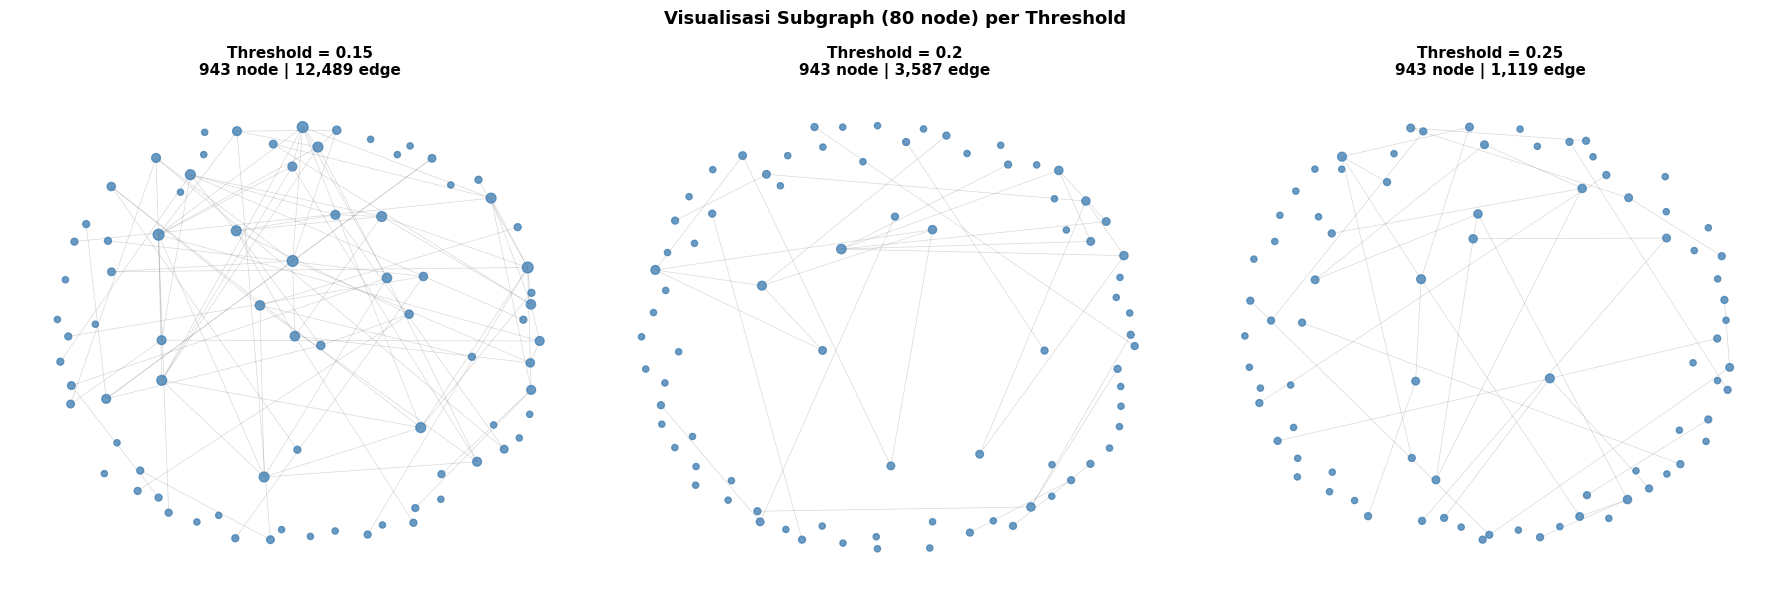

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 6)
)

for ax, (t, G) in zip(axes, graphs.items()):

    # Ambil connected component terbesar
    largest_cc = max(
        nx.connected_components(G),
        key=len
    )

    # Ambil sample node
    sample_nodes = list(largest_cc)[:80]

    # Membentuk subgraph
    G_sub = G.subgraph(sample_nodes).copy()

    # Layout graph
    pos = nx.spring_layout(
        G_sub,
        seed=42,
        k=0.8
    )

    # Degree node
    degrees = dict(G_sub.degree())

    # Ukuran node berdasarkan degree
    node_size = [
        20 + degrees[n] * 5
        for n in G_sub.nodes()
    ]

    # Visualisasi node
    nx.draw_networkx_nodes(
        G_sub,
        pos,
        node_size=node_size,
        node_color='steelblue',
        alpha=0.8,
        ax=ax
    )

    # Visualisasi edge
    nx.draw_networkx_edges(
        G_sub,
        pos,
        alpha=0.3,
        edge_color='gray',
        width=0.5,
        ax=ax
    )

    ax.set_title(
        f'Threshold = {t}\n'
        f'{G.number_of_nodes()} node | '
        f'{G.number_of_edges():,} edge',
        fontweight='bold',
        fontsize=11
    )

    ax.axis('off')

fig.suptitle(
    'Visualisasi Subgraph (80 node) per Threshold',
    fontsize=13,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

Threshold 0,15 menghasilkan graph yang relatif padat dengan banyak hubungan antar node. Struktur graph terlihat masih saling terhubung sehingga komunitas pengguna belum terlihat secara jelas. Pada threshold 0,20 graph mulai membentuk kelompok-kelompok kecil yang lebih terpisah. Hubungan antar pengguna menjadi lebih selektif sehingga pola komunitas mulai terlihat dengan lebih baik dibandingkan threshold sebelumnya. Sementara itu pada threshold 0,25 graph menjadi jauh lebih sparse dan banyak node yang terisolasi tanpa hubungan dengan node lain. Hal tersebut menunjukkan bahwa threshold terlalu tinggi dapat menyebabkan hilangnya banyak hubungan antar pengguna yang sebenarnya masih relevan. Berdasarkan hasil visualisasi dan analisis struktur graph, threshold 0,20 dipilih sebagai threshold utama karena memberikan keseimbangan antara jumlah edge, keterhubungan graph, dan pembentukan komunitas pengguna.


## Statistik Tiap Graph

In [ ]:
print("="*55)
print("GRAPH CONSTRUCTION & STRUKTUR NETWORK")
print("="*55)

def get_graph_stats(G, threshold):
    """Hitung statistik lengkap sebuah graph."""
    degrees       = [d for _, d in G.degree()]
    weights       = [d['weight'] for u,v,d in G.edges(data=True)]
    components    = list(nx.connected_components(G))
    largest_cc    = max(components, key=len)
    isolated      = [n for n in G.nodes() if G.degree(n) == 0]

    return {
        'threshold'      : threshold,
        'n_nodes'        : G.number_of_nodes(),
        'n_edges'        : G.number_of_edges(),
        'density'        : round(nx.density(G), 6),
        'avg_degree'     : round(np.mean(degrees), 2) if degrees else 0,
        'max_degree'     : max(degrees) if degrees else 0,
        'min_degree'     : min(degrees) if degrees else 0,
        'median_degree'  : round(np.median(degrees), 2) if degrees else 0,
        'n_components'   : len(components),
        'largest_cc_size': len(largest_cc),
        'largest_cc_pct' : round(len(largest_cc)/G.number_of_nodes()*100, 2),
        'n_isolated'     : len(isolated),
        'isolated_pct'   : round(len(isolated)/G.number_of_nodes()*100, 2),
        'avg_weight'     : round(np.mean(weights), 4) if weights else 0,
        'max_weight'     : round(max(weights), 4) if weights else 0,
        'min_weight'     : round(min(weights), 4) if weights else 0,
    }

stats_list = [get_graph_stats(G, t) for t, G in graphs.items()]
stats_df   = pd.DataFrame(stats_list).set_index('threshold')

print("Statistik Graph per Threshold:")
display(stats_df.T)

GRAPH CONSTRUCTION & STRUKTUR NETWORK
Statistik Graph per Threshold:


threshold,0.15,0.20,0.25
n_nodes,943.000000,943.000000,943.000000
n_edges,12489.000000,3587.000000,1119.000000
density,0.028119,0.008076,0.002519
avg_degree,26.490000,7.610000,2.370000
max_degree,147.000000,64.000000,28.000000
min_degree,0.000000,0.000000,0.000000
median_degree,21.000000,4.000000,1.000000
n_components,11.000000,157.000000,454.000000
largest_cc_size,933.000000,776.000000,442.000000
largest_cc_pct,98.940000,82.290000,46.870000


Tabel di atas menampilkan statistik struktur graph secara lengkap
untuk ketiga nilai threshold eksperimen. Seluruh graph memiliki
jumlah node yang sama yaitu 943 pengguna, namun struktur
konektivitasnya berbeda secara signifikan. Pada threshold 0,15
terbentuk 12.489 edge dengan density 0,028 dan rata-rata degree
26,49, yang menunjukkan bahwa setiap pengguna rata-rata terhubung
dengan 26 pengguna lain. Pada threshold 0,20 jumlah edge berkurang
menjadi 3.587 dengan rata-rata degree 7,61, sedangkan pada threshold
0,25 hanya terbentuk 1.119 edge dengan rata-rata degree 2,37.
Penurunan jumlah edge yang signifikan ini menunjukkan bahwa
peningkatan threshold menyebabkan hanya pasangan pengguna dengan
kemiripan preferensi yang benar-benar tinggi yang terhubung dalam
jaringan.

## Degree Distribution

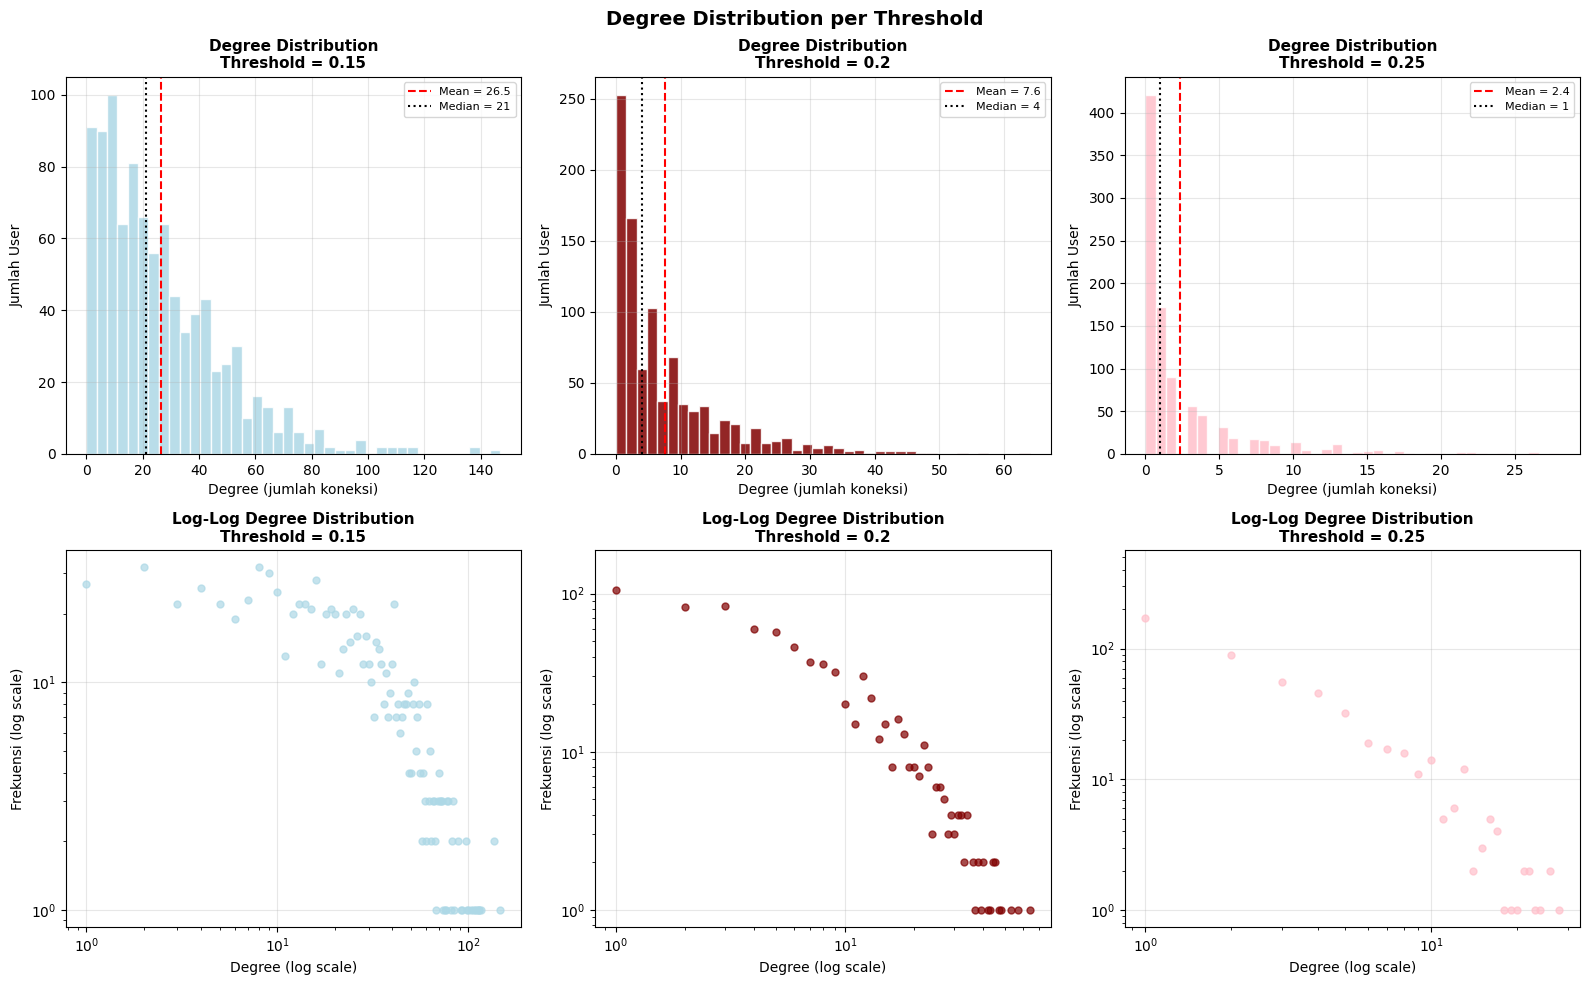

Ringkasan Degree Distribution:
 Threshold |   Min |   Max |    Mean |  Median |     Std
-------------------------------------------------------
      0.15 |     0 |   147 |   26.49 |      21 |   22.37
      0.20 |     0 |    64 |    7.61 |       4 |    9.13
      0.25 |     0 |    28 |    2.37 |       1 |    4.02


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
colors = ['lightblue', 'maroon', 'pink']

for col, (t, G) in enumerate(graphs.items()):
    degrees = [d for _, d in G.degree()]
    color   = colors[col]

    # Baris atas: histogram degree distribution
    ax = axes[0, col]
    ax.hist(degrees, bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(degrees), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {np.mean(degrees):.1f}')
    ax.axvline(np.median(degrees), color='black', linestyle=':', linewidth=1.5,
               label=f'Median = {np.median(degrees):.0f}')
    ax.set_title(f'Degree Distribution\nThreshold = {t}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Degree (jumlah koneksi)')
    ax.set_ylabel('Jumlah User')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # Baris bawah: log-log plot (ciri khas skala bebas / power law)
    ax2 = axes[1, col]
    degree_count = pd.Series(degrees).value_counts().sort_index()
    ax2.loglog(degree_count.index, degree_count.values,
               'o', color=color, alpha=0.7, markersize=5)
    ax2.set_title(f'Log-Log Degree Distribution\nThreshold = {t}',
                  fontweight='bold', fontsize=11)
    ax2.set_xlabel('Degree (log scale)')
    ax2.set_ylabel('Frekuensi (log scale)')
    ax2.grid(alpha=0.3)

fig.suptitle('Degree Distribution per Threshold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Cetak ringkasan degree
print("Ringkasan Degree Distribution:")
print(f"{'Threshold':>10} | {'Min':>5} | {'Max':>5} | {'Mean':>7} | "
      f"{'Median':>7} | {'Std':>7}")
print("-" * 55)
for t, G in graphs.items():
    deg = [d for _, d in G.degree()]
    print(f"{t:>10.2f} | {min(deg):>5} | {max(deg):>5} | "
          f"{np.mean(deg):>7.2f} | {np.median(deg):>7.0f} | "
          f"{np.std(deg):>7.2f}")

Histogram degree distribution menunjukkan bahwa distribusi koneksi
antar pengguna bersifat right-skewed (condong ke kanan) pada ketiga
threshold. Sebagian besar pengguna memiliki degree yang rendah,
sementara hanya sedikit pengguna yang memiliki degree sangat tinggi.
Pola ini mengindikasikan adanya karakteristik jaringan skala bebas
(scale-free network), di mana terdapat sejumlah kecil pengguna
yang berperan sebagai hub dengan koneksi yang jauh lebih banyak
dibandingkan pengguna lainnya. Pada threshold 0,15 degree tertinggi
mencapai 147, menurun menjadi 64 pada threshold 0,20, dan 28 pada
threshold 0,25. Hal ini konsisten dengan menurunnya kepadatan graph
seiring meningkatnya threshold.

## Isolated Nodes Analysis

Analisis Isolated Nodes per Threshold:

Threshold 0.15:
   User terisolasi  :   10 (1.1%)
   User terhubung   :  933 (98.9%)

Threshold 0.2:
   User terisolasi  :  147 (15.6%)
   User terhubung   :  796 (84.4%)

Threshold 0.25:
   User terisolasi  :  421 (44.6%)
   User terhubung   :  522 (55.4%)



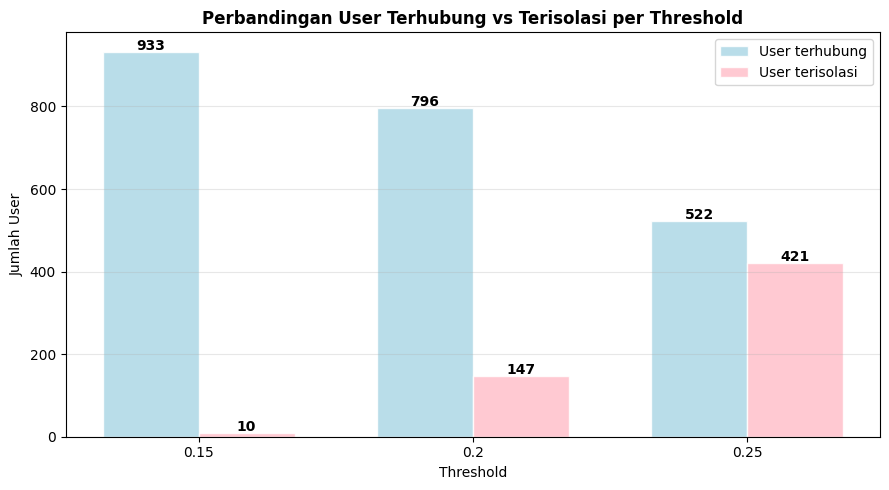

In [ ]:
print("Analisis Isolated Nodes per Threshold:\n")

fig, ax = plt.subplots(figsize=(9, 5))
t_labels      = [str(t) for t in graphs.keys()]
isolated_cnts = []
active_cnts   = []

for t, G in graphs.items():
    isolated = len([n for n in G.nodes() if G.degree(n) == 0])
    active   = G.number_of_nodes() - isolated
    isolated_cnts.append(isolated)
    active_cnts.append(active)
    print(f"Threshold {t}:")
    print(f"   User terisolasi  : {isolated:>4} ({isolated/G.number_of_nodes()*100:.1f}%)")
    print(f"   User terhubung   : {active:>4} ({active/G.number_of_nodes()*100:.1f}%)\n")

x    = np.arange(len(t_labels))
w    = 0.35
bars1 = ax.bar(x - w/2, active_cnts, w, label='User terhubung',
               color='lightblue', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + w/2, isolated_cnts, w, label='User terisolasi',
               color='pink', alpha=0.85, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=10, fontweight='bold')

ax.set_title('Perbandingan User Terhubung vs Terisolasi per Threshold',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Threshold'); ax.set_ylabel('Jumlah User')
ax.set_xticks(x); ax.set_xticklabels(t_labels)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Analisis isolated nodes menunjukkan adanya peningkatan jumlah
pengguna yang tidak memiliki koneksi seiring meningkatnya threshold.
Pada threshold 0,15 hanya terdapat 10 pengguna terisolasi (1,06%),
yang berarti hampir seluruh pengguna berhasil terhubung dalam
jaringan. Pada threshold 0,20 jumlah pengguna terisolasi meningkat
menjadi 147 (15,59%), sedangkan pada threshold 0,25 sebanyak 421
pengguna (44,64%) tidak memiliki koneksi sama sekali. Pengguna
terisolasi ini merupakan pengguna yang tidak memiliki pasangan
dengan nilai cosine similarity maupun jumlah co-rated items yang
memenuhi syarat pembentukan edge. Tingginya jumlah isolated nodes
pada threshold 0,25 menjadi salah satu pertimbangan utama mengapa
threshold tersebut kurang ideal untuk analisis komunitas dan sistem
rekomendasi.

## Largest Connected Component (LCC) Analysis

Analisis Largest Connected Component:

Threshold 0.15:
   Jumlah komponen         : 11
   LCC size                : 933 user (98.9%)
   Komponen ukuran 1 (solo): 10
   Komponen ukuran 2-5     : 0
   Komponen ukuran > 5     : 1

Threshold 0.2:
   Jumlah komponen         : 157
   LCC size                : 776 user (82.3%)
   Komponen ukuran 1 (solo): 147
   Komponen ukuran 2-5     : 9
   Komponen ukuran > 5     : 1

Threshold 0.25:
   Jumlah komponen         : 454
   LCC size                : 442 user (46.9%)
   Komponen ukuran 1 (solo): 421
   Komponen ukuran 2-5     : 32
   Komponen ukuran > 5     : 1



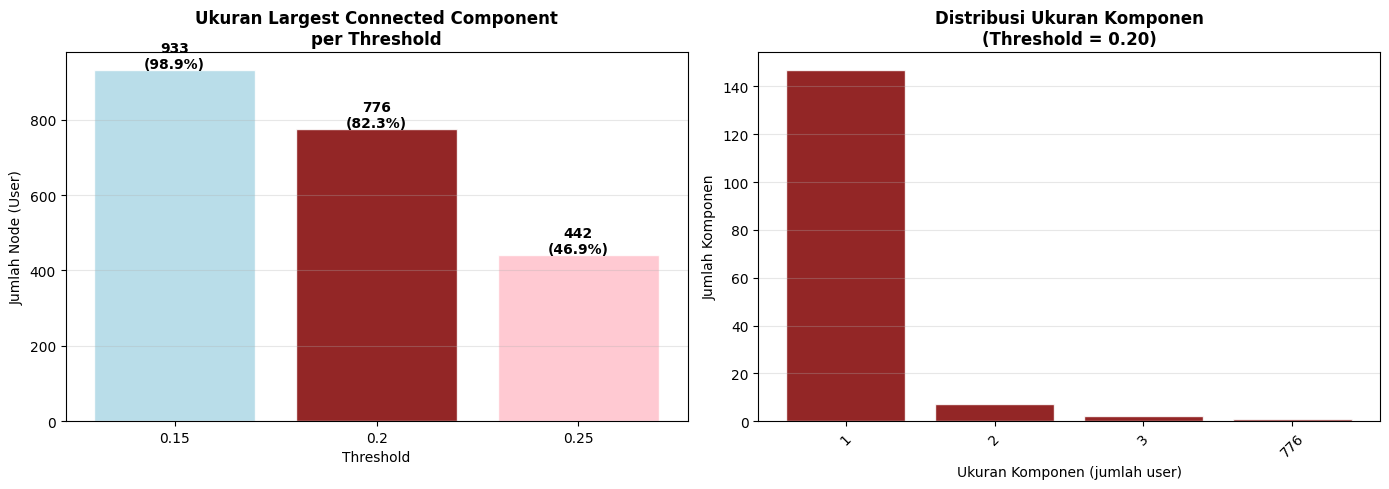

In [ ]:
print("Analisis Largest Connected Component:\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

lcc_sizes  = []
lcc_pcts   = []
comp_dists = {}

for t, G in graphs.items():
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    lcc        = components[0]
    lcc_sizes.append(len(lcc))
    lcc_pcts.append(len(lcc) / G.number_of_nodes() * 100)

    # Distribusi ukuran semua komponen
    sizes = [len(c) for c in components]
    comp_dists[t] = sizes

    print(f"Threshold {t}:")
    print(f"   Jumlah komponen         : {len(components)}")
    print(f"   LCC size                : {len(lcc)} user "
          f"({len(lcc)/G.number_of_nodes()*100:.1f}%)")
    print(f"   Komponen ukuran 1 (solo): "
          f"{sum(1 for s in sizes if s==1)}")
    print(f"   Komponen ukuran 2-5     : "
          f"{sum(1 for s in sizes if 2<=s<=5)}")
    print(f"   Komponen ukuran > 5     : "
          f"{sum(1 for s in sizes if s>5)}\n")

# Plot LCC size per threshold
axes[0].bar([str(t) for t in graphs.keys()], lcc_sizes,
            color=['lightblue','maroon','pink'],
            alpha=0.85, edgecolor='white')
for i, (v, p) in enumerate(zip(lcc_sizes, lcc_pcts)):
    axes[0].text(i, v + 5, f'{v}\n({p:.1f}%)',
                 ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Ukuran Largest Connected Component\nper Threshold',
                  fontweight='bold')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Jumlah Node (User)')
axes[0].grid(axis='y', alpha=0.3)

# Plot distribusi ukuran komponen (threshold 0.20)
comp_sizes_020 = comp_dists[0.20]
size_counts    = pd.Series(comp_sizes_020).value_counts().sort_index()
axes[1].bar(size_counts.index.astype(str), size_counts.values,
            color='maroon', alpha=0.85, edgecolor='white')
axes[1].set_title('Distribusi Ukuran Komponen\n(Threshold = 0.20)',
                  fontweight='bold')
axes[1].set_xlabel('Ukuran Komponen (jumlah user)')
axes[1].set_ylabel('Jumlah Komponen')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Analisis largest connected component (LCC) menunjukkan perbedaan
yang signifikan antar threshold. Pada threshold 0,15, LCC mencakup
933 pengguna atau 98,94% dari total, yang berarti hampir seluruh
pengguna berada dalam satu komponen jaringan yang saling terhubung.
Pada threshold 0,20, LCC berkurang menjadi 776 pengguna (82,29%),
yang masih menunjukkan konektivitas jaringan yang cukup baik.
Sebaliknya, pada threshold 0,25, LCC hanya mencakup 442 pengguna
(46,87%), menunjukkan bahwa jaringan telah terfragmentasi secara
signifikan. Distribusi ukuran komponen pada threshold 0,20
memperlihatkan bahwa di samping LCC yang dominan, terdapat banyak
komponen kecil berukuran 2 hingga 5 pengguna, yang merupakan
kelompok pengguna dengan preferensi sangat spesifik yang hanya
mirip dengan sedikit pengguna lain.

## Distribusi Bobot Edge

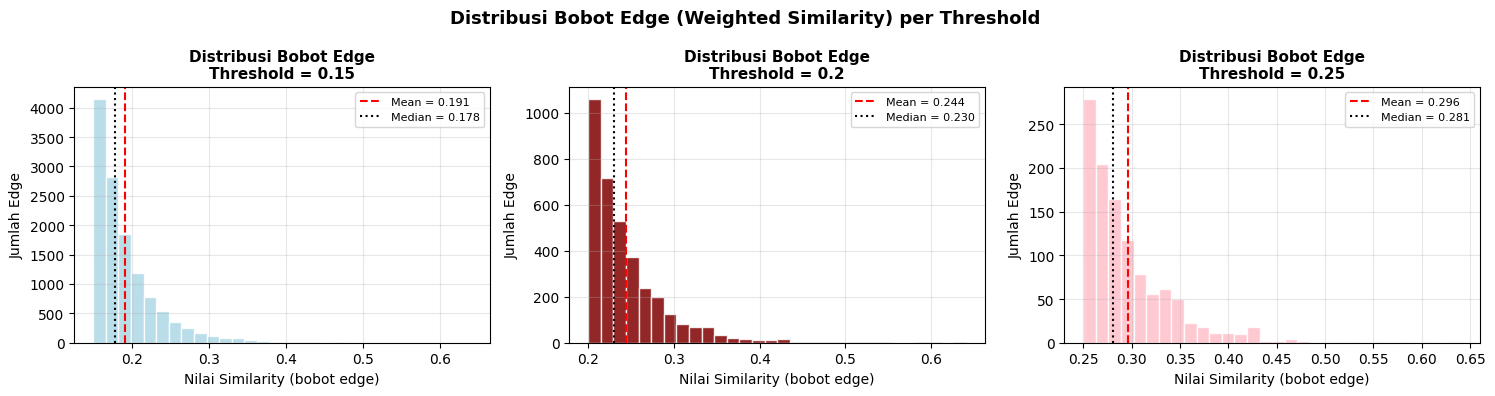

Ringkasan Bobot Edge:
 Threshold |    Min |    Max |    Mean |  Median |     Std
---------------------------------------------------------
      0.15 | 0.1500 | 0.6408 |  0.1911 |  0.1781 |  0.0431
      0.20 | 0.2000 | 0.6408 |  0.2438 |  0.2297 |  0.0457
      0.25 | 0.2500 | 0.6408 |  0.2962 |  0.2811 |  0.0478


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (t, G), color in zip(axes, graphs.items(), colors):
    weights = [d['weight'] for u, v, d in G.edges(data=True)]

    ax.hist(weights, bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(np.mean(weights), color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {np.mean(weights):.3f}')
    ax.axvline(np.median(weights), color='black', linestyle=':', linewidth=1.5,
               label=f'Median = {np.median(weights):.3f}')
    ax.set_title(f'Distribusi Bobot Edge\nThreshold = {t}',
                 fontweight='bold', fontsize=11)
    ax.set_xlabel('Nilai Similarity (bobot edge)')
    ax.set_ylabel('Jumlah Edge')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

fig.suptitle('Distribusi Bobot Edge (Weighted Similarity) per Threshold',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Ringkasan Bobot Edge:")
print(f"{'Threshold':>10} | {'Min':>6} | {'Max':>6} | "
      f"{'Mean':>7} | {'Median':>7} | {'Std':>7}")
print("-" * 57)
for t, G in graphs.items():
    w = [d['weight'] for u,v,d in G.edges(data=True)]
    print(f"{t:>10.2f} | {min(w):>6.4f} | {max(w):>6.4f} | "
          f"{np.mean(w):>7.4f} | {np.median(w):>7.4f} | "
          f"{np.std(w):>7.4f}")

Distribusi bobot edge menggambarkan sebaran nilai cosine similarity
pada pasangan pengguna yang berhasil terhubung dalam graph. Pada
threshold 0,15 distribusi bobot terkonsentrasi di rentang 0,15
hingga 0,25, dengan rata-rata bobot 0,19. Pada threshold 0,20
distribusi bergeser ke kanan dengan rata-rata bobot 0,24, sedangkan
pada threshold 0,25 rata-rata bobot mencapai 0,29. Pola ini
menunjukkan bahwa semakin tinggi threshold, edge yang tersisa
merupakan koneksi dengan kualitas similarity yang semakin tinggi.
Dengan kata lain, meskipun jumlah edge berkurang, setiap edge yang
terbentuk merepresentasikan hubungan kemiripan yang lebih kuat dan
lebih bermakna antar pengguna.

## Visualisasi Perbandingan Graph 3 Threshold

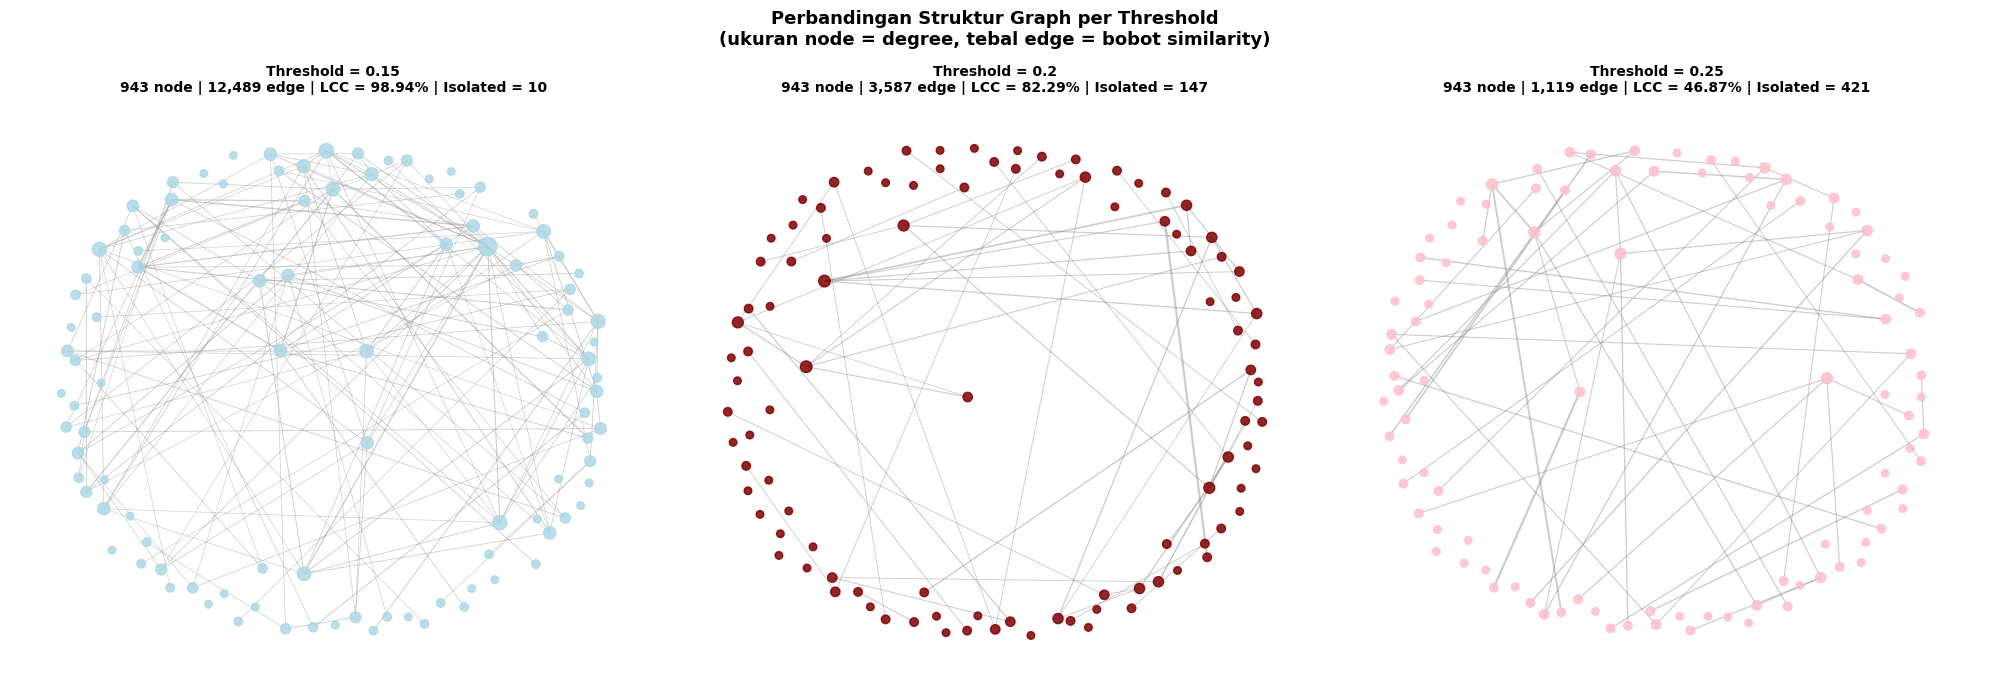

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, (t, G), color in zip(axes, graphs.items(), colors):
    # Ambil LCC, sample 100 node
    lcc          = max(nx.connected_components(G), key=len)
    sample_nodes = list(lcc)[:100]
    G_sub        = G.subgraph(sample_nodes).copy()
    pos          = nx.spring_layout(G_sub, seed=42, k=1.0)

    # Ukuran node = degree, warna edge = weight
    degrees      = dict(G_sub.degree())
    node_sizes   = [30 + degrees[n] * 8 for n in G_sub.nodes()]
    edge_weights = [G_sub[u][v]['weight'] for u, v in G_sub.edges()]
    edge_widths  = [w * 3 for w in edge_weights]

    nx.draw_networkx_nodes(G_sub, pos, node_size=node_sizes,
                           node_color=color, alpha=0.85, ax=ax)
    nx.draw_networkx_edges(G_sub, pos, alpha=0.4, edge_color='gray',
                           width=edge_widths, ax=ax)

    stats = get_graph_stats(G, t)
    ax.set_title(
        f'Threshold = {t}\n'
        f'{stats["n_nodes"]} node | {stats["n_edges"]:,} edge | '
        f'LCC = {stats["largest_cc_pct"]}% | '
        f'Isolated = {stats["n_isolated"]}',
        fontweight='bold', fontsize=10
    )
    ax.axis('off')

fig.suptitle(
    'Perbandingan Struktur Graph per Threshold\n'
    '(ukuran node = degree, tebal edge = bobot similarity)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

Visualisasi perbandingan struktur graph pada ketiga threshold
memperlihatkan perbedaan karakteristik jaringan secara visual.
Ukuran node merepresentasikan degree pengguna, sehingga node yang
lebih besar menunjukkan pengguna dengan lebih banyak koneksi dalam
jaringan. Ketebalan edge merepresentasikan bobot similarity,
sehingga edge yang lebih tebal menunjukkan pasangan pengguna yang
lebih mirip preferensinya.

Pada threshold 0,15 terlihat banyak node berukuran besar yang
tersebar merata, mengindikasikan adanya banyak pengguna yang
berperan sebagai hub dalam jaringan. Pada threshold 0,20 ukuran
node mulai bervariasi dengan beberapa hub yang lebih menonjol,
sementara edge yang tersisa cenderung lebih tebal yang menandakan
kemiripan yang lebih kuat. Pada threshold 0,25 sebagian besar node
berukuran kecil dengan sedikit koneksi, dan jaringan tampak lebih
terfragmentasi dengan banyak node yang tidak terhubung ke komponen
utama.

## Ringkasan Insight Graph Construction

In [ ]:
print("="*60)
print("RINGKASAN INSIGHT STRUKTUR GRAPH")
print("="*60)

for t, G in graphs.items():
    s    = get_graph_stats(G, t)
    degs = [d for _, d in G.degree()]
    print(f"\nThreshold {t}:")
    print(f"  • {s['n_isolated']} user terisolasi ({s['isolated_pct']}%) "
          f"— tidak punya tetangga di graph")
    print(f"  • LCC mencakup {s['largest_cc_size']} user "
          f"({s['largest_cc_pct']}% dari total)")
    print(f"  • Degree terbesar: {s['max_degree']} koneksi "
          f"— user paling 'populer' dalam jaringan")
    print(f"  • Avg degree: {s['avg_degree']} "
          f"— rata-rata tiap user punya {s['avg_degree']} tetangga")
    print(f"  • Avg bobot edge: {s['avg_weight']} "
          f"— rata-rata kemiripan pasangan yang terhubung")

print(f"\n{'='*60}")
print("Insight Pengaruh Threshold:")
print(f"{'='*60}")
print("  • Threshold lebih tinggi → graph lebih sparse →")
print("    lebih banyak user terisolasi → komunitas lebih kecil")
print("  • Threshold 0.20 = sweet spot: LCC masih cukup besar,")
print("    tapi edge yang terbentuk sudah cukup selektif")
print("  • Bobot edge meningkat seiring threshold naik —")
print("    edge yang tersisa adalah yang benar-benar berkualitas")

RINGKASAN INSIGHT STRUKTUR GRAPH

Threshold 0.15:
  • 10 user terisolasi (1.06%) — tidak punya tetangga di graph
  • LCC mencakup 933 user (98.94% dari total)
  • Degree terbesar: 147 koneksi — user paling 'populer' dalam jaringan
  • Avg degree: 26.49 — rata-rata tiap user punya 26.49 tetangga
  • Avg bobot edge: 0.1911 — rata-rata kemiripan pasangan yang terhubung

Threshold 0.2:
  • 147 user terisolasi (15.59%) — tidak punya tetangga di graph
  • LCC mencakup 776 user (82.29% dari total)
  • Degree terbesar: 64 koneksi — user paling 'populer' dalam jaringan
  • Avg degree: 7.61 — rata-rata tiap user punya 7.61 tetangga
  • Avg bobot edge: 0.2438 — rata-rata kemiripan pasangan yang terhubung

Threshold 0.25:
  • 421 user terisolasi (44.64%) — tidak punya tetangga di graph
  • LCC mencakup 442 user (46.87% dari total)
  • Degree terbesar: 28 koneksi — user paling 'populer' dalam jaringan
  • Avg degree: 2.37 — rata-rata tiap user punya 2.37 tetangga
  • Avg bobot edge: 0.2962 — rata-r

Berdasarkan analisis struktur graph secara menyeluruh, threshold
0,20 terbukti menjadi konfigurasi yang paling optimal untuk
penelitian ini. Threshold tersebut menghasilkan keseimbangan
terbaik antara jumlah koneksi yang cukup representatif (3.587
edge), tingkat isolated nodes yang masih dapat diterima (15,59%),
dan LCC yang mencakup mayoritas pengguna (82,29%). Threshold 0,15
menghasilkan graph yang terlalu padat sehingga hubungan antar
pengguna menjadi kurang selektif, sedangkan threshold 0,25
menyebabkan terlalu banyak pengguna terisolasi yang tidak dapat
memperoleh rekomendasi dari jaringan. Temuan ini memperkuat
keputusan penggunaan threshold 0,20 sebagai konfigurasi utama
dalam tahap analisis graph dan sistem rekomendasi selanjutnya.

# **Community Detection**

Pada tahap ini digunakan algoritma Louvain Community Detection untuk mengelompokkan pengguna ke dalam komunitas berdasarkan kemiripan preferensi film. Algoritma Louvain dipilih karena mampu memaksimalkan nilai modularity secara efisien pada network berukuran besar. Nilai modularity digunakan sebagai ukuran kualitas komunitas semakin tinggi nilainya, semakin baik pemisahan antar komunitas yang terbentuk.



In [ ]:
community_results = {}
for t, G in graphs.items():
    if G.number_of_edges() == 0:
        print(f"Threshold {t}: graph kosong, skip.")
        continue
    partition  = community_louvain.best_partition(
                     G, weight='weight', random_state=42)
    n_comm     = len(set(partition.values()))
    modularity = community_louvain.modularity(
                     partition, G, weight='weight')
    community_results[t] = {
        'partition' : partition,
        'n_comm'    : n_comm,
        'modularity': modularity
    }
    print(f"Threshold {t} → {n_comm:>3} komunitas | "
          f"modularity = {modularity:.4f}")

Threshold 0.15 →  17 komunitas | modularity = 0.4299
Threshold 0.2 → 168 komunitas | modularity = 0.5017
Threshold 0.25 → 465 komunitas | modularity = 0.6017


Semakin tinggi threshold maka jumlah komunitas dan nilai modularity meningkat. Hal tersebut menunjukkan bahwa graph menjadi lebih selektif sehingga komunitas yang terbentuk semakin spesifik. Threshold 0,20 dipilih sebagai graph utama karena menghasilkan keseimbangan antara jumlah komunitas, connectivity graph, dan nilai modularity.
Pada threshold 0,20 terbentuk 168 komunitas dengan modularity sebesar 0,5017. Nilai tersebut menunjukkan bahwa struktur komunitas pada graph tergolong cukup baik. Ukuran komunitas yang terbentuk juga bervariasi. Komunitas terbesar terdiri dari 203 pengguna, sedangkan beberapa komunitas hanya berisi satu pengguna. Rata-rata ukuran komunitas adalah 5,6 pengguna. Perbedaan ukuran komunitas menunjukkan bahwa terdapat kelompok pengguna dengan preferensi film yang mirip, namun terdapat juga pengguna dengan preferensi yang lebih unik.


## Analisis Detail Komunitas

In [ ]:
partition_main = community_results[0.20]['partition']
n_comm_main    = community_results[0.20]['n_comm']
comm_sizes     = pd.Series(partition_main).value_counts().sort_index()

print(f"Jumlah komunitas : {n_comm_main}")
print(f"Modularity       : {community_results[0.20]['modularity']:.4f}")
print(f"\nStatistik ukuran komunitas:")
print(f"   Min  : {comm_sizes.min()} user")
print(f"   Max  : {comm_sizes.max()} user")
print(f"   Mean : {comm_sizes.mean():.1f} user")
print(f"\nJumlah user per komunitas:")
display(comm_sizes.rename('jumlah_user').to_frame())

Jumlah komunitas : 168
Modularity       : 0.5017

Statistik ukuran komunitas:
   Min  : 1 user
   Max  : 203 user
   Mean : 5.6 user

Jumlah user per komunitas:


,jumlah_user
0,203
1,80
2,1
3,113
4,28
...,...
163,1
164,1
165,1
166,1


Setelah community detection selesai, dilakukan analisis detail menggunakan threshold 0,20 sebagai konfigurasi utama. Threshold ini dipilih karena menghasilkan keseimbangan yang baik antara jumlah komunitas, konektivitas graph, dan nilai modularity.

## Visualisasi Graph Komunitas

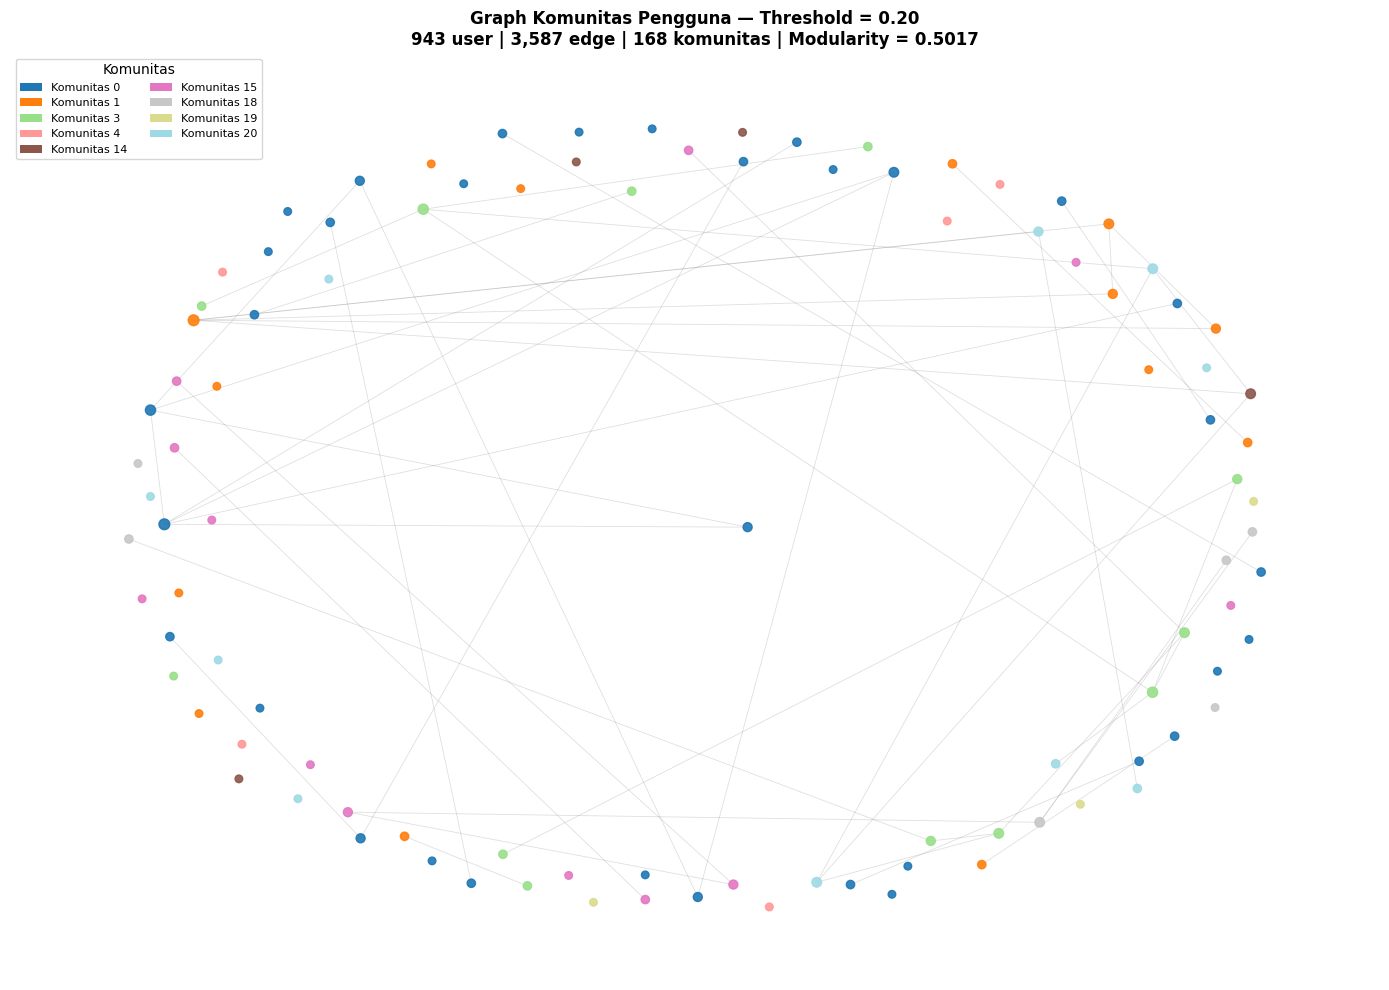

In [ ]:
largest_cc   = max(nx.connected_components(G_main), key=len)
sample_nodes = list(largest_cc)[:100]
G_viz        = G_main.subgraph(sample_nodes).copy()
pos          = nx.spring_layout(G_viz, seed=42, k=1.2)

comm_list   = [partition_main.get(n, 0) for n in G_viz.nodes()]
unique_comm = sorted(set(comm_list))
colors      = cm.tab20(np.linspace(0, 1, max(len(unique_comm), 1)))
color_map   = {c: colors[i] for i, c in enumerate(unique_comm)}
node_colors = [color_map[c] for c in comm_list]
degrees     = dict(G_viz.degree())
node_sizes  = [30 + degrees[n] * 6 for n in G_viz.nodes()]

fig, ax = plt.subplots(figsize=(14, 10))
nx.draw_networkx_nodes(G_viz, pos, node_color=node_colors,
                       node_size=node_sizes, alpha=0.9, ax=ax)
nx.draw_networkx_edges(G_viz, pos, alpha=0.25,
                       edge_color='gray', width=0.6, ax=ax)

legend_elements = [
    Patch(facecolor=color_map[c], label=f'Komunitas {c}')
    for c in unique_comm[:12]
]
ax.legend(handles=legend_elements, loc='upper left',
          fontsize=8, title='Komunitas', ncol=2)
ax.set_title(
    f'Graph Komunitas Pengguna — Threshold = 0.20\n'
    f'{G_main.number_of_nodes()} user | '
    f'{G_main.number_of_edges():,} edge | '
    f'{n_comm_main} komunitas | '
    f'Modularity = {community_results[0.20]["modularity"]:.4f}',
    fontsize=12, fontweight='bold'
)
ax.axis('off')
plt.tight_layout()
plt.show()


node merepresentasikan pengguna dan edge menunjukkan hubungan similarity antar pengguna. Warna node menunjukkan komunitas hasil Louvain Community Detection. Terlihat bahwa pengguna dengan preferensi film yang mirip cenderung berkumpul dalam kelompok yang sama. Hubungan di dalam komunitas terlihat lebih rapat dibanding hubungan antar komunitas, sehingga menunjukkan bahwa proses community detection berhasil memisahkan kelompok pengguna berdasarkan kemiripan preferensi film. Ukuran node menunjukkan jumlah koneksi yang dimiliki pengguna. Semakin besar ukuran node maka semakin banyak hubungan similarity yang dimiliki pengguna tersebut dalam graph.


## Hasil Community Detection

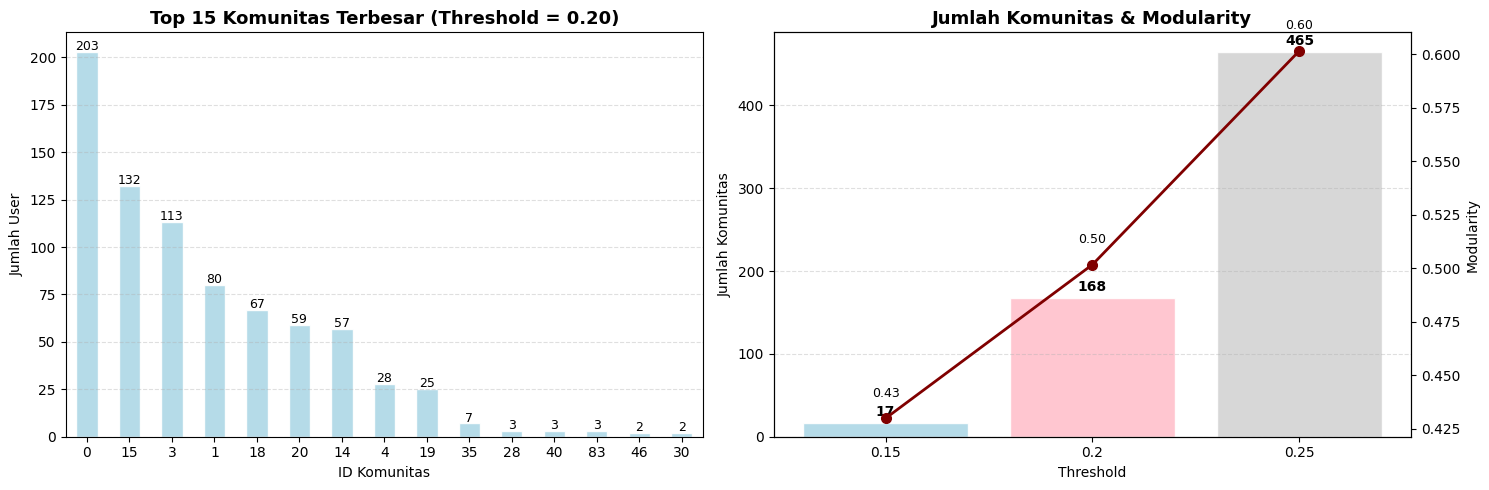

Hasil disimpan ke 'user_communities.csv'

RINGKASAN HASIL
Threshold 0.15 → 12,489 edge | 17 komunitas | modularity=0.4299
Threshold 0.2 → 3,587 edge | 168 komunitas | modularity=0.5017
Threshold 0.25 → 1,119 edge | 465 komunitas | modularity=0.6017


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# TOP 15 KOMUNITAS TERBESAR
top_comm = comm_sizes.sort_values(ascending=False).head(15)

top_comm.plot(
    kind='bar',
    ax=axes[0],
    color='lightblue',
    edgecolor='white',
    alpha=0.9
)

axes[0].set_title(
    'Top 15 Komunitas Terbesar (Threshold = 0.20)',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_xlabel('ID Komunitas')
axes[0].set_ylabel('Jumlah User')

axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

# Label jumlah user di atas bar
for i, v in enumerate(top_comm.values):
    axes[0].text(
        i, v + 1,
        str(v),
        ha='center',
        fontsize=9
    )

# JUMLAH KOMUNITAS & MODULARITY
t_labels = list(community_results.keys())

n_comms = [
    community_results[t]['n_comm']
    for t in t_labels
]

mods = [
    community_results[t]['modularity']
    for t in t_labels
]

bars = axes[1].bar(
    [str(t) for t in t_labels],
    n_comms,
    color=['lightblue', 'pink', 'lightgray'],
    edgecolor='white',
    alpha=0.9
)

axes[1].set_title(
    'Jumlah Komunitas & Modularity',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Jumlah Komunitas')

axes[1].grid(axis='y', linestyle='--', alpha=0.4)

# Label jumlah komunitas
for bar, val in zip(bars, n_comms):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 8,
        str(val),
        ha='center',
        fontsize=10,
        fontweight='bold'
    )

# Secondary axis modularity
ax2b = axes[1].twinx()

ax2b.plot(
    [str(t) for t in t_labels],
    mods,
    marker='o',
    linewidth=2,
    markersize=7,
    color='maroon'
)

ax2b.set_ylabel('Modularity')

# Label modularity
for x, y in zip([str(t) for t in t_labels], mods):
    ax2b.text(
        x, y + 0.01,
        f'{y:.2f}',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# SIMPAN HASIL=
partition_df = pd.Series(partition_main, name='community_id')
partition_df.index.name = 'user_id'
partition_df.reset_index().to_csv(
    'user_communities.csv',
    index=False
)

print("Hasil disimpan ke 'user_communities.csv'")

print(f"\n{'='*55}")
print("RINGKASAN HASIL")
print(f"{'='*55}")

for t, G in graphs.items():

    res = community_results.get(t, {})

    print(
        f"Threshold {t} → "
        f"{G.number_of_edges():,} edge | "
        f"{res.get('n_comm','?')} komunitas | "
        f"modularity={res.get('modularity',0):.4f}"
    )

Grafik kiri menunjukkan 15 komunitas dengan jumlah anggota terbanyak. Terlihat bahwa sebagian besar komunitas memiliki anggota yang relatif sedikit, sementara hanya beberapa komunitas yang memiliki anggota dalam jumlah besar. Grafik kanan menunjukkan bahwa semakin tinggi threshold yang digunakan, semakin banyak komunitas yang terbentuk dan semakin tinggi nilai modularitynya, karena graph menjadi lebih selektif dalam mempertahankan hubungan antar pengguna.



## Menggabungkan dengan dataset

In [ ]:
# Menggabungkan rating dengan komunitas user
ratings_comm = ratings.merge(
    partition_df,
    on='user_id',
    how='left'
)

# Menggabungkan dengan data film
ratings_movies = ratings_comm.merge(
    movies[['item_id', 'title', 'main_genre']],
    on='item_id',
    how='left'
)

ratings_movies.head()

,user_id,item_id,rating,timestamp,user_mean,rating_norm,community_id,title,main_genre
0,196,242,3,881250949,3.631579,-0.631579,46,Kolya,Comedy
1,186,302,3,891717742,3.481928,-0.481928,1,L.A. Confidential,Crime
2,244,51,2,880606923,3.662338,-1.662338,0,Legends of the Fall,Drama
3,166,346,1,886397596,3.526316,-2.526316,14,Jackie Brown,Crime
4,298,474,4,884182806,4.039683,-0.039683,0,Dr. Strangelove or: How I Learned to Stop Worr...,Sci-Fi


Pada tahap ini dilakukan proses penggabungan dataset rating pengguna dengan dataset komunitas dan dataset film. Tujuan penggabungan ini adalah untuk mengetahui genre film yang disukai oleh setiap komunitas pengguna.

Proses pertama dilakukan dengan menggabungkan data rating pengguna dengan hasil community detection berdasarkan user_id. Setelah itu, data tersebut digabungkan kembali dengan dataset film (u.item) berdasarkan item_id untuk memperoleh informasi judul film dan genre utama.

## Genre Dominan pada Setiap Komunitas beserta Visualisasi

Setelah penggabungan dataset, dihitung genre film yang paling sering muncul (genre dominan) pada setiap komunitas. Genre dominan diambil berdasarkan jumlah interaksi rating terbanyak pada tiap komunitas, sehingga mencerminkan preferensi kolektif pengguna dalam komunitas tersebut.

In [ ]:
# Menghitung genre dominan tiap komunitas
community_genre = (
    ratings_movies
    .groupby(['community_id', 'main_genre'])
    .size()
    .reset_index(name='count')
)

# Ambil genre dominan
dominant_genre = (
    community_genre
    .sort_values(['community_id', 'count'], ascending=[True, False])
    .groupby('community_id')
    .head(1)
)

print(dominant_genre.head(10))

     community_id main_genre  count
0               0     Action  12449
23              1      Drama   1619
36              2     Comedy     39
49              3      Drama   1642
58              4     Action    749
77              5     Comedy     62
91              6      Drama     16
101             7      Drama     23
115             8      Drama     36
129             9      Drama     98


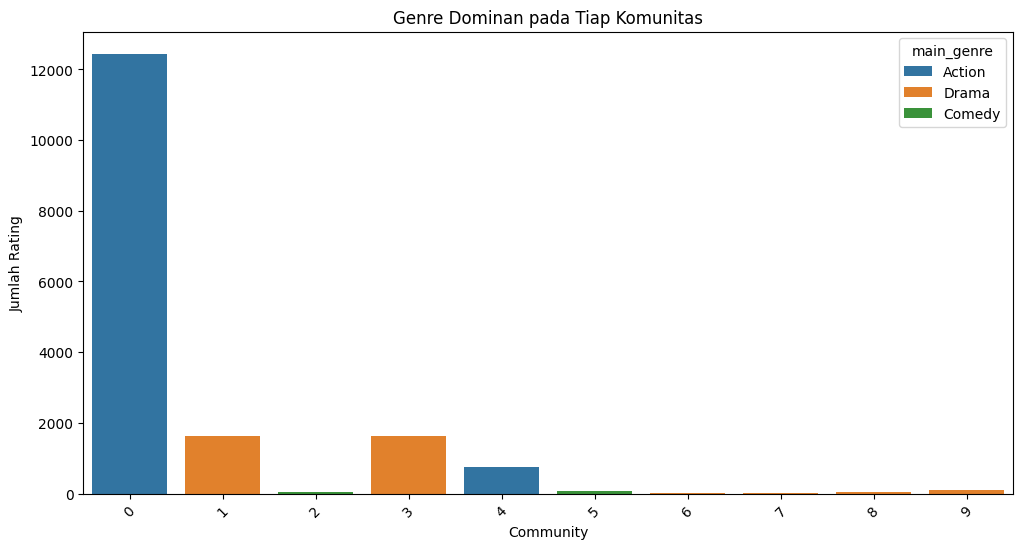

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.barplot(
    data=dominant_genre.head(10),
    x='community_id',
    y='count',
    hue='main_genre'
)

plt.title('Genre Dominan pada Tiap Komunitas')
plt.xlabel('Community')
plt.ylabel('Jumlah Rating')
plt.xticks(rotation=45)
plt.show()

Berdasarkan visualisasi di atas, terlihat bahwa setiap komunitas memiliki genre dominan yang berbeda-beda. Hal ini membuktikan bahwa algoritma Louvain berhasil mengelompokkan pengguna berdasarkan kesamaan selera film, bukan hanya berdasarkan frekuensi rating saja.

## Karakteristik Komunitas

Analisis karakteristik komunitas dilakukan untuk mengetahui jumlah pengguna, jumlah film, rata-rata rating, dan genre dominan pada masing-masing komunitas.

In [ ]:
community_characteristics = (
    ratings_movies
    .groupby('community_id')
    .agg(
        total_users=('user_id', 'nunique'),
        total_movies=('item_id', 'nunique'),
        avg_rating=('rating', 'mean')
    )
    .reset_index()
)

community_characteristics = community_characteristics.merge(
    dominant_genre[['community_id', 'main_genre']],
    on='community_id',
    how='left'
)

community_characteristics.head(10)

,community_id,total_users,total_movies,avg_rating,main_genre
0,0,203,939,3.490712,Action
1,1,80,775,3.608138,Drama
2,2,1,115,3.704348,Comedy
3,3,113,699,3.451217,Drama
4,4,28,711,3.540916,Action
5,5,1,175,3.445714,Comedy
6,6,1,51,4.392157,Drama
7,7,1,78,4.269231,Drama
8,8,1,138,4.347826,Drama
9,9,1,267,3.895131,Drama


## User Paling Berpengaruh dalam Komunitas beserta Visualisasi

Untuk mengidentifikasi pengguna yang paling berpengaruh dalam setiap komunitas, digunakan metrik degree centrality. Degree centrality mengukur seberapa banyak koneksi yang dimiliki suatu node dibanding total node lain dalam graph. Pengguna dengan degree centrality tertinggi dalam komunitasnya dianggap sebagai central user yang memiliki preferensi paling representatif di komunitas tersebut.

In [ ]:
# Degree centrality
centrality = nx.degree_centrality(G_main)

centrality_df = pd.DataFrame({
    'user_id': list(centrality.keys()),
    'centrality': list(centrality.values())
})

# Gabungkan komunitas
centrality_df = centrality_df.merge(
    partition_df,
    on='user_id',
    how='left'
)

# Top user tiap komunitas
top_users = (
    centrality_df
    .sort_values(['community_id', 'centrality'], ascending=[True, False])
    .groupby('community_id')
    .head(1)
)

print(top_users.head(10))

     user_id  centrality  community_id
275      276    0.067941             0
643      644    0.030786             1
926      927    0.000000             2
543      544    0.056263             3
591      592    0.033970             4
10        11    0.000000             5
11        12    0.000000             6
941      942    0.000000             7
15        16    0.000000             8
17        18    0.000000             9


Pengguna dengan centrality tertinggi di tiap komunitas berpotensi menjadi acuan rekomendasi film untuk anggota komunitas lainnya, karena preferensinya paling banyak terhubung dengan pengguna lain yang memiliki selera serupa.

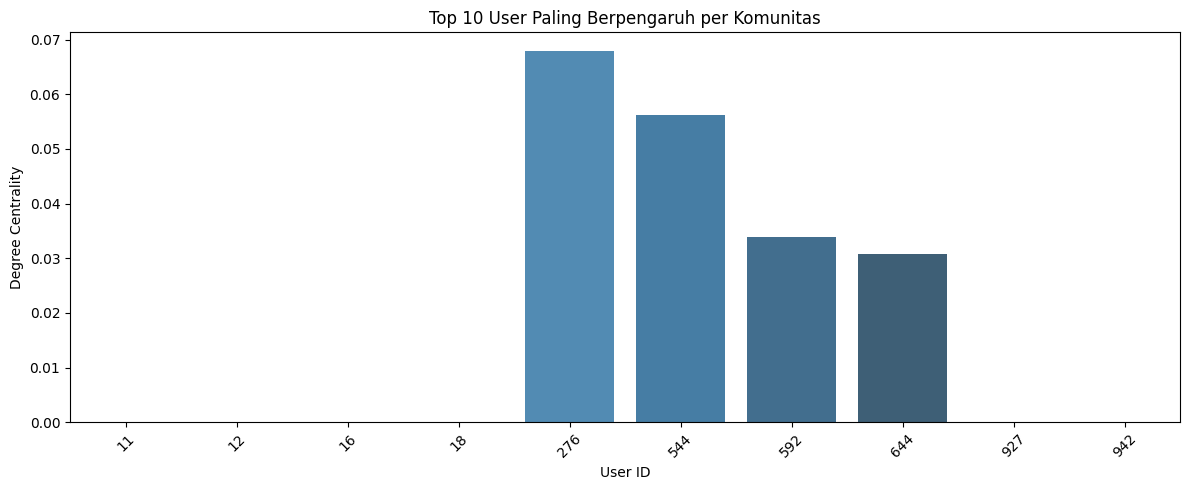

In [ ]:
plt.figure(figsize=(12, 5))
top10 = top_users.head(10).sort_values('centrality', ascending=False)
sns.barplot(data=top10, x='user_id', y='centrality', palette='Blues_d')
plt.title('Top 10 User Paling Berpengaruh per Komunitas')
plt.xlabel('User ID')
plt.ylabel('Degree Centrality')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Insight
*   Terbentuk 168 komunitas dari 943 pengguna dengan nilai modularity 0,5017, yang menunjukkan struktur komunitas yang cukup baik.
*   Sebagian besar komunitas berukuran kecil (1–5 anggota), namun terdapat beberapa komunitas besar dengan lebih dari 100 anggota. Hal ini mencerminkan bahwa mayoritas pengguna memiliki preferensi yang cukup unik, sementara sebagian kecil berbagi selera yang lebih umum.
*   Setiap komunitas memiliki genre dominan yang berbeda, membuktikan bahwa hasil pengelompokan berbasis kemiripan rating ini berhasil menangkap pola preferensi genre secara kolektif.
*   Pengguna dengan degree centrality tertinggi di masing-masing komunitas berpotensi dijadikan acuan rekomendasi karena preferensinya paling banyak bersinggungan dengan anggota komunitasnya.








#Analisis Centrality

Analisis centrality dilakukan untuk mengetahui tingkat pengaruh pengguna dalam graph recommendation system. Pada penelitian ini digunakan dua jenis centrality


1. Degree centrality
digunakan untuk mengukur banyaknya koneksi similarity yang dimiliki pengguna terhadap pengguna lain
2. betweenness centrality digunakan untuk mengukur peran pengguna sebagai penghubung antar komunitas dalam graph

In [ ]:
import pandas as pd
import numpy as np
import networkx as nx

import matplotlib.pyplot as plt
import seaborn as sns


Degree Centrality



Nilai degree centrality menunjukkan seberapa banyak hubungan similarity yang dimiliki setiap pengguna terhadap pengguna lainnya di dalam jaringan.

In [ ]:
print("="*60)
print("DEGREE CENTRALITY")
print("="*60)

# Hitung degree centrality
degree = nx.degree_centrality(G_main)

# Buat dataframe
degree_df = pd.DataFrame({
    'user_id': list(degree.keys()),
    'degree_centrality': list(degree.values())
})

display(degree_df.head())

DEGREE CENTRALITY


,user_id,degree_centrality
0,1,0.005308
1,2,0.019108
2,3,0.004246
3,4,0.015924
4,5,0.003185


5 data awal menunjukkan bahwa sebagian besar user hanya terhubung dengan sedikit pengguna lain dalam graph recommendation system.


Betweenness Centrality

 Semakin tinggi nilainya, maka semakin penting peran user tersebut sebagai penghubung antar komunitas.


In [ ]:
print("="*60)
print("BETWEENNESS CENTRALITY")
print("="*60)

# Hitung betweenness centrality
betweenness = nx.betweenness_centrality(
    G_main,
    weight='weight'
)

# Buat dataframe
betweenness_df = pd.DataFrame({
    'user_id': list(betweenness.keys()),
    'betweenness_centrality': list(betweenness.values())
})

display(betweenness_df.head())


BETWEENNESS CENTRALITY


,user_id,betweenness_centrality
0,1,0.000250
1,2,0.003637
2,3,0.000115
3,4,0.001207
4,5,0.000065


Hal ini menandakan bahwa mayoritas user tidak berperan besar sebagai penghubung antar bagian graph.

Gabungkan dengan Community

In [ ]:
community_df = pd.DataFrame({
    'user_id': list(partition_main.keys()),
    'community_id': list(partition_main.values())
})

# Gabungkan seluruh data
analysis_df = degree_df.merge(
    betweenness_df,
    on='user_id'
)

analysis_df = analysis_df.merge(
    community_df,
    on='user_id',
    how='left'
)

print("="*60)
print("DATA CENTRALITY")
print("="*60)

display(analysis_df.head())

DATA CENTRALITY


,user_id,degree_centrality,betweenness_centrality,community_id
0,1,0.005308,0.000250,0
1,2,0.019108,0.003637,1
2,3,0.004246,0.000115,20
3,4,0.015924,0.001207,3
4,5,0.003185,0.000065,0


Top 10 Degree Centrality

In [ ]:
top_degree = (
    analysis_df
    .sort_values(
        'degree_centrality',
        ascending=False
    )
    .head(10)
)

print("="*60)
print("TOP 10 DEGREE CENTRALITY")
print("="*60)

display(
    top_degree[
        [
            'user_id',
            'community_id',
            'degree_centrality'
        ]
    ]
)

TOP 10 DEGREE CENTRALITY


,user_id,community_id,degree_centrality
275,276,0,0.067941
292,293,0,0.060510
543,544,3,0.056263
925,926,20,0.050955
525,526,3,0.049894
509,510,14,0.047771
625,626,3,0.047771
932,933,0,0.046709
456,457,0,0.046709
104,105,3,0.045648


Berdasarkan hasil top 10 degree centrality, user 276 memiliki nilai degree centrality tertinggi sebesar 0.067941, diikuti user 293 sebesar 0.060510 dan user 544 sebesar 0.056263. Hasil ini menunjukkan bahwa user tersebut memiliki koneksi similarity paling banyak dengan pengguna lain sehingga menjadi pusat hubungan dalam graph recommendation system. Selain itu, user dengan degree centrality tinggi berasal dari beberapa komunitas berbeda seperti komunitas 0, 3, 14, 18, dan 20. Hal ini menunjukkan bahwa konektivitas tinggi tidak hanya terpusat pada satu komunitas saja.

Top 10 Betweenness

In [ ]:
top_between = (
    analysis_df
    .sort_values(
        'betweenness_centrality',
        ascending=False
    )
    .head(10)
)

print("="*60)
print("TOP 10 BETWEENNESS CENTRALITY")
print("="*60)

display(
    top_between[
        [
            'user_id',
            'community_id',
            'betweenness_centrality'
        ]
    ]
)

TOP 10 BETWEENNESS CENTRALITY


,user_id,community_id,betweenness_centrality
292,293,0,0.034331
275,276,0,0.025774
456,457,0,0.024698
591,592,4,0.023916
25,26,3,0.023382
932,933,0,0.023106
548,549,18,0.021873
176,177,4,0.020520
525,526,3,0.019955
536,537,0,0.019545


Berdasarkan hasil top betweenness centrality, user 293 memiliki nilai tertinggi sebesar 0.034331, diikuti user 276 sebesar 0.025774 dan user 457 sebesar 0.024698. Hal ini menunjukkan bahwa user tersebut memiliki peran penting sebagai penghubung antar kelompok pengguna dalam graph. Selain memiliki banyak koneksi, user-user tersebut juga berfungsi sebagai jalur penghubung utama antar komunitas sehingga memiliki pengaruh besar terhadap struktur network recommendation system.


Visualisasi Degree Centrality

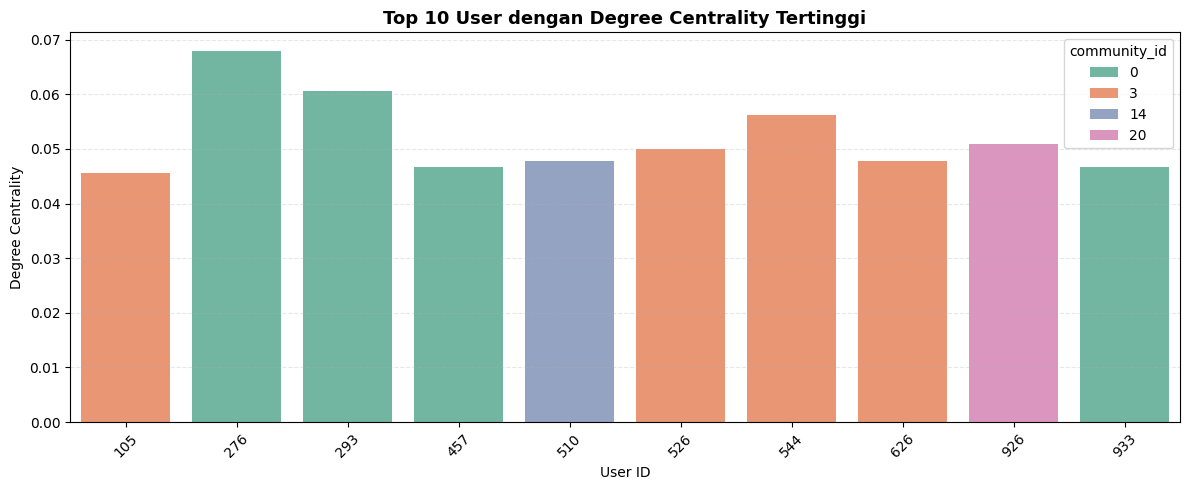

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=top_degree,
    x='user_id',
    y='degree_centrality',
    hue='community_id',
    dodge=False,
    palette='Set2'
)

plt.title(
    'Top 10 User dengan Degree Centrality Tertinggi',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('User ID')
plt.ylabel('Degree Centrality')

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()


Visualisasi degree centrality memperlihatkan bahwa terdapat perbedaan nilai centrality yang cukup jelas antar pengguna. User 276 dan user 293 terlihat memiliki nilai paling tinggi dibandingkan user lainnya. Selain itu, warna batang menunjukkan bahwa user dengan koneksi tertinggi berasal dari komunitas yang berbeda-beda, terutama komunitas 0 dan komunitas 3 yang cukup dominan pada posisi top centrality.


Visualisasi Betweenness Centrality

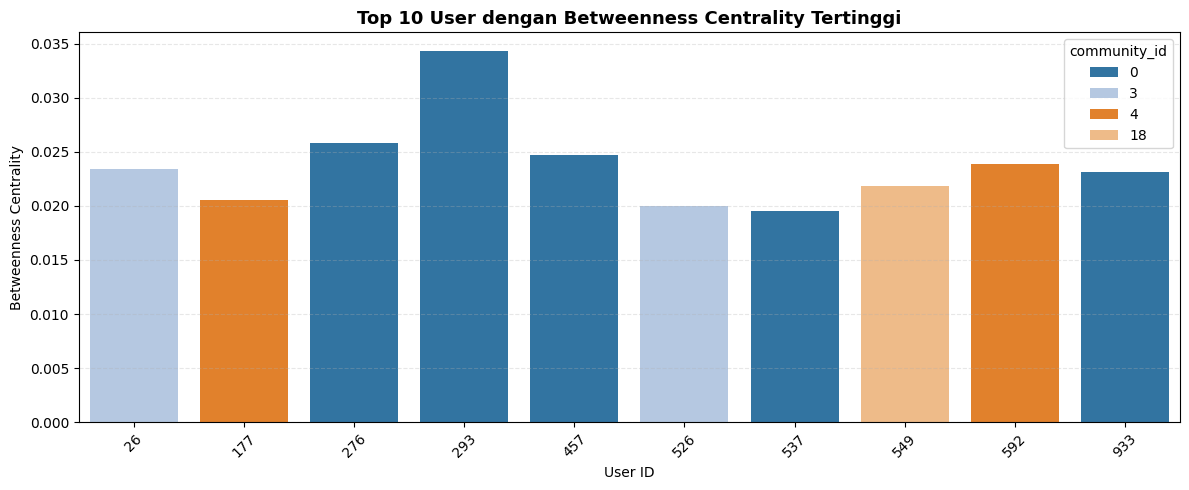

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=top_between,
    x='user_id',
    y='betweenness_centrality',
    hue='community_id',
    dodge=False,
    palette='tab20'
)

plt.title(
    'Top 10 User dengan Betweenness Centrality Tertinggi',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('User ID')
plt.ylabel('Betweenness Centrality')

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

Grafik betweenness centrality menunjukkan bahwa hanya beberapa pengguna yang memiliki nilai cukup tinggi, sedangkan sebagian besar lainnya relatif rendah. User 293 terlihat sebagai pengguna dengan peran penghubung paling dominan dalam graph, diikuti oleh user 276 dan 457. Hal ini menunjukkan bahwa hanya sedikit node yang berfungsi sebagai bridge antar bagian jaringan recommendation system.


Scatter Plot

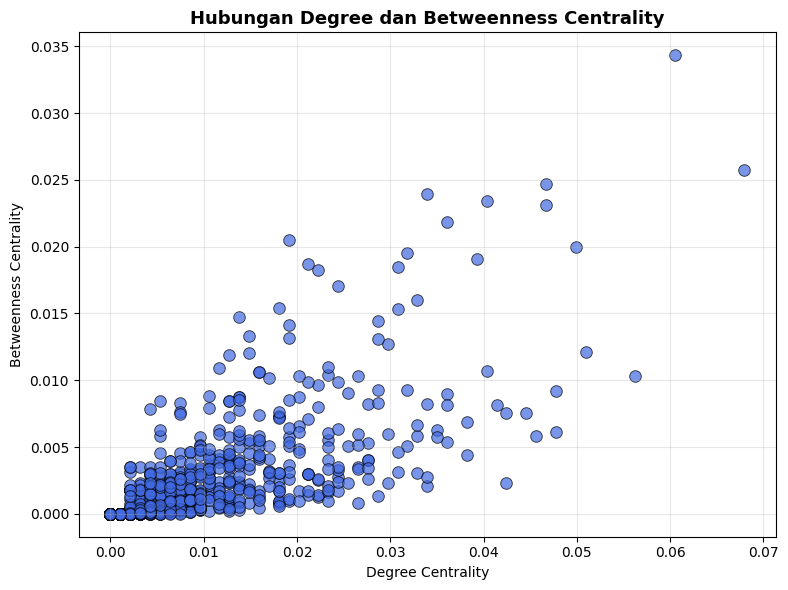

In [ ]:
#Scatter Plot Degree vs Betweenness
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=analysis_df,
    x='degree_centrality',
    y='betweenness_centrality',
    color='royalblue',
    s=70,
    edgecolor='black',
    alpha=0.7
)

plt.title(
    'Hubungan Degree dan Betweenness Centrality',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Degree Centrality')
plt.ylabel('Betweenness Centrality')

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()



Scatter plot menunjukkan adanya hubungan positif antara degree centrality dan betweenness centrality. Titik-titik data cenderung meningkat seiring bertambahnya nilai degree centrality. Namun terlihat bahwa sebagian besar user terkonsentrasi di area kiri bawah grafik, yang menunjukkan bahwa mayoritas pengguna memiliki koneksi dan pengaruh yang rendah dalam graph. Selain itu, terdapat beberapa titik yang berada jauh dari kumpulan utama data, yang menunjukkan adanya user dengan pengaruh jauh lebih besar dibandingkan pengguna lainnya.


Statistik Centrality

In [ ]:
print("="*60)
print("STATISTIK CENTRALITY")
print("="*60)

print("\nStatistik Degree Centrality")

display(
    analysis_df[
        'degree_centrality'
    ].describe()
)

print("\nStatistik Betweenness Centrality")

display(
    analysis_df[
        'betweenness_centrality'
    ].describe()
)

STATISTIK CENTRALITY

Statistik Degree Centrality


,degree_centrality
count,943.000000
mean,0.008076
std,0.009701
min,0.000000
25%,0.001062
50%,0.004246
75%,0.011146
max,0.067941



Statistik Betweenness Centrality


,betweenness_centrality
count,943.000000
mean,0.002039
std,0.003729
min,0.000000
25%,0.000000
50%,0.000483
75%,0.002421
max,0.034331


Hasil statistik menunjukkan bahwa rata-rata degree centrality sebesar 0.008076 dengan nilai maksimum sebesar 0.067941. Sementara itu, rata-rata betweenness centrality sebesar 0.002039 dengan nilai maksimum sebesar 0.034331. Perbedaan yang cukup besar antara nilai rata-rata dan maksimum menunjukkan adanya beberapa user yang jauh lebih dominan dibandingkan pengguna lain dalam network recommendation system.


Korelasi Degree dan Betweenness

In [ ]:
correlation = analysis_df[
    [
        'degree_centrality',
        'betweenness_centrality'
    ]
].corr()

print("="*60)
print("KORELASI CENTRALITY")
print("="*60)

display(correlation)

KORELASI CENTRALITY


,degree_centrality,betweenness_centrality
degree_centrality,1.000000,0.741749
betweenness_centrality,0.741749,1.000000


Hasil korelasi menunjukkan nilai hubungan sebesar 0.741749 antara degree centrality dan betweenness centrality. Nilai ini menunjukkan korelasi positif yang cukup kuat. Artinya, pengguna yang memiliki banyak koneksi cenderung juga memiliki peran penting sebagai penghubung antar pengguna dalam graph recommendation system.



Top User Influencer

In [ ]:
analysis_df['influence_score'] = (
    analysis_df['degree_centrality'] +
    analysis_df['betweenness_centrality']
)

# Top influencer
top_influencer = (
    analysis_df
    .sort_values(
        'influence_score',
        ascending=False
    )
    .head(10)
)

print("="*60)
print("TOP USER INFLUENCER")
print("="*60)

display(
    top_influencer[
        [
            'user_id',
            'community_id',
            'degree_centrality',
            'betweenness_centrality',
            'influence_score'
        ]
    ]
)

TOP USER INFLUENCER


,user_id,community_id,degree_centrality,betweenness_centrality,influence_score
292,293,0,0.060510,0.034331,0.094841
275,276,0,0.067941,0.025774,0.093715
456,457,0,0.046709,0.024698,0.071407
525,526,3,0.049894,0.019955,0.069849
932,933,0,0.046709,0.023106,0.069816
543,544,3,0.056263,0.010290,0.066553
25,26,3,0.040340,0.023382,0.063722
925,926,20,0.050955,0.012127,0.063082
895,896,0,0.039278,0.019101,0.058379
548,549,18,0.036093,0.021873,0.057966


Visualisasi User Influencer

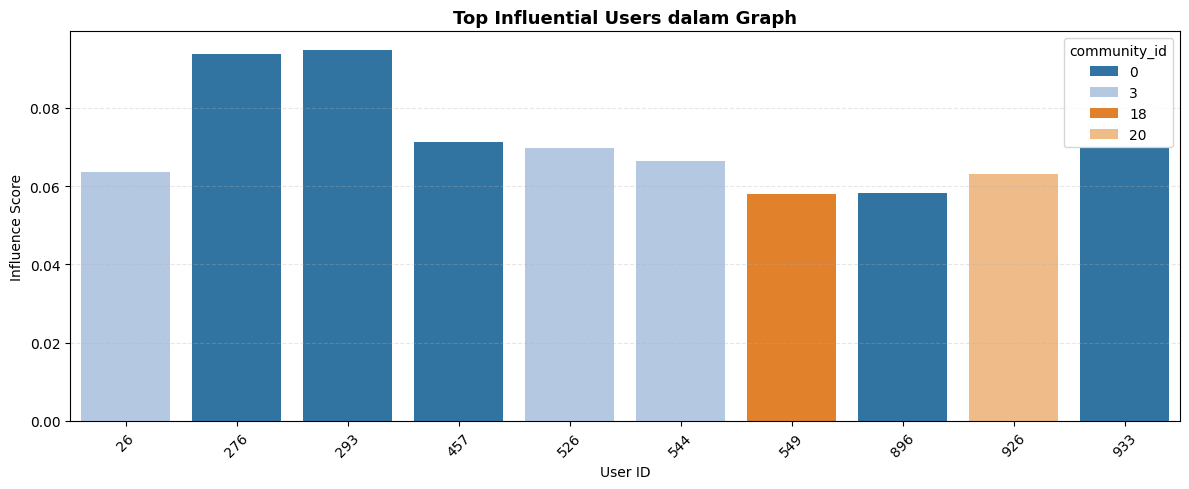

In [ ]:
plt.figure(figsize=(12,5))

sns.barplot(
    data=top_influencer,
    x='user_id',
    y='influence_score',
    hue='community_id',
    dodge=False,
    palette='tab20'
)

plt.title(
    'Top Influential Users dalam Graph',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('User ID')
plt.ylabel('Influence Score')

plt.xticks(rotation=45)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.3
)

plt.tight_layout()
plt.show()

Visualisasi influence score menunjukkan bahwa user 293 dan user 276 memiliki pengaruh paling dominan dalam network recommendation system. Selain itu, terlihat adanya selisih influence score yang cukup jelas antara beberapa user teratas dengan pengguna lainnya. Hal ini menunjukkan bahwa struktur graph recommendation system cenderung terpusat pada beberapa node utama yang memiliki koneksi luas sekaligus peran penting sebagai penghubung antar komunitas.

# **Recommendation System**

Pada tahap ini dibangun sistem rekomendasi film berbasis graph menggunakan hubungan similarity antar pengguna yang telah terbentuk pada graph. Rekomendasi diberikan berdasarkan film yang disukai oleh neighbor (tetangga) pengguna yang memiliki preferensi serupa dalam jaringan.

Sistem rekomendasi menggunakan weighted recommendation score, yaitu skor rekomendasi dihitung berdasarkan kombinasi rating neighbor dan nilai similarity antar pengguna.

## **Train-Test Split**

Sebelum evaluasi dilakukan, dataset dibagi menjadi data training dan data testing. Data training digunakan untuk membangun recommendation system, sedangkan data testing digunakan untuk evaluasi performa rekomendasi.

In [ ]:
from sklearn.model_selection import train_test_split

train_list = []
test_list  = []

for user_id, group in ratings.groupby('user_id'):

    # minimal interaksi
    if len(group) < 10:
        continue

    train, test = train_test_split(
        group,
        test_size=0.2,
        random_state=42
    )

    train_list.append(train)
    test_list.append(test)

train_df = pd.concat(train_list)
test_df  = pd.concat(test_list)

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (75598, 6)
Test : (19370, 6)


## **Weighted Recommendation Score**

Skor rekomendasi dihitung menggunakan metode weighted average similarity:

$$
Score(i)=
\frac{
\sum (sim(u,v)\times rating(v,i))
}{
\sum sim(u,v)
}
$$

Keterangan:

- $sim(u,v)$ = nilai similarity antara user target $u$ dan neighbor $v$
- $rating(v,i)$ = rating yang diberikan neighbor $v$ terhadap film $i$

Semakin tinggi similarity neighbor terhadap user target, semakin besar pengaruh rating neighbor terhadap skor rekomendasi film.

In [ ]:
def recommend_movies(
    user_id,
    G,
    ratings_df,
    similarity_df,
    movies_df,
    top_n=10,
    top_k_neighbors=20
):

    # Ambil TOP-K neighbor paling mirip
    neighbors = sorted(
        list(G.neighbors(user_id)),
        key=lambda x: similarity_df.loc[user_id, x],
        reverse=True
    )[:top_k_neighbors]

    # Jika user tidak punya neighbor
    if len(neighbors) == 0:
        return pd.DataFrame()

    # Film yang sudah ditonton user
    watched_movies = ratings_df[
        ratings_df['user_id'] == user_id
    ]['item_id'].tolist()

    # Ambil rating neighbor
    neighbor_ratings = ratings_df[
        ratings_df['user_id'].isin(neighbors)
    ]

    # Filter film yang belum ditonton
    neighbor_ratings = neighbor_ratings[
        ~neighbor_ratings['item_id'].isin(watched_movies)
    ]

    # Hitung weighted recommendation score
    scores = {}

    for _, row in neighbor_ratings.iterrows():

        neighbor_id = row['user_id']
        movie_id    = row['item_id']
        rating      = row['rating']

        # similarity user-target vs neighbor
        sim_score = similarity_df.loc[
            user_id,
            neighbor_id
        ]

        # skip similarity negatif / nol
        if sim_score <= 0:
            continue

        # weighted score
        weighted_score = sim_score * rating

        # init dictionary movie
        if movie_id not in scores:

            scores[movie_id] = {
                'weighted_sum': 0,
                'sim_sum': 0,
                'neighbor_support': 0
            }

        # akumulasi weighted score
        scores[movie_id]['weighted_sum'] += weighted_score

        # akumulasi similarity
        scores[movie_id]['sim_sum'] += sim_score

        # jumlah neighbor pendukung
        scores[movie_id]['neighbor_support'] += 1

    # Final recommendation score
    recommendations = []

    for movie_id, val in scores.items():

        # hindari pembagian nol
        if val['sim_sum'] == 0:
            continue

        # weighted average similarity
        final_score = (
            val['weighted_sum'] /
            val['sim_sum']
        )

        recommendations.append([
            movie_id,
            round(final_score, 4),
            val['neighbor_support']
        ])

    # DataFrame hasil rekomendasi
    rec_df = pd.DataFrame(
        recommendations,
        columns=[
            'item_id',
            'score',
            'neighbor_support'
        ]
    )

    # sorting:
    # 1. score tertinggi
    # 2. support neighbor terbesar

    rec_df = rec_df.sort_values(
        ['score', 'neighbor_support'],
        ascending=[False, False]
    )

    # Gabungkan informasi film
    rec_df = rec_df.merge(
        movies_df[
            ['item_id', 'title', 'main_genre']
        ],
        on='item_id',
        how='left'
    )

    return rec_df.head(top_n)

Fungsi recommendation system bekerja dengan memanfaatkan hubungan antar pengguna dalam graph. Neighbor pengguna diambil berdasarkan edge similarity pada graph, kemudian film yang sudah pernah ditonton pengguna akan difilter agar tidak muncul kembali dalam rekomendasi. Skor rekomendasi dihitung menggunakan weighted similarity sehingga film dari neighbor dengan similarity lebih tinggi memiliki kontribusi lebih besar terhadap hasil rekomendasi.

## Top-10 Recommendation untuk User 10

In [ ]:
user_id = 10

top10_rec = recommend_movies(
    user_id=user_id,
    G=G_main,
    ratings_df=train_df,
    similarity_df=similarity_df,
    movies_df=movies,
    top_n=10
)

display(top10_rec)

,item_id,score,neighbor_support,title,main_genre
0,633.0,5.0,2,"Christmas Carol, A",Drama
1,515.0,5.0,2,"Boot, Das",Action
2,205.0,5.0,2,Patton,Drama
3,520.0,5.0,1,"Great Escape, The",Adventure
4,503.0,5.0,1,"Candidate, The",Drama
5,183.0,5.0,1,Alien,Action
6,525.0,5.0,1,"Big Sleep, The",Film-Noir
7,178.0,5.0,1,12 Angry Men,Drama
8,136.0,5.0,1,Mr. Smith Goes to Washington,Drama
9,191.0,5.0,1,Amadeus,Drama


Hasil rekomendasi menunjukkan bahwa sistem berhasil memberikan film-film dengan skor prediksi tertinggi berdasarkan rating dari neighbor (user yang memiliki kemiripan preferensi). Film seperti Christmas Carol, A, Boot, Das, dan Patton memperoleh skor maksimum 5.0 dengan neighbor_support sebanyak 2, yang berarti terdapat dua neighbor yang memberikan rating tinggi terhadap film tersebut sehingga film dianggap sangat relevan untuk direkomendasikan kepada user target.

Sementara itu, beberapa film lain seperti Great Escape, The, Alien, dan 12 Angry Men juga memperoleh skor 5.0 tetapi hanya didukung oleh satu neighbor (neighbor_support = 1). Hal ini menunjukkan bahwa film tersebut mendapat rating sangat tinggi dari satu user yang sangat mirip dengan user target.

Secara umum, nilai score merepresentasikan prediksi tingkat ketertarikan user terhadap film berdasarkan weighted average similarity, sedangkan neighbor_support menunjukkan jumlah neighbor yang mendukung rekomendasi tersebut. Semakin besar neighbor_support, maka rekomendasi cenderung lebih stabil dan lebih meyakinkan karena didukung oleh lebih banyak user yang mirip.

## Visualisasi Hasil Rekomendasi User 10

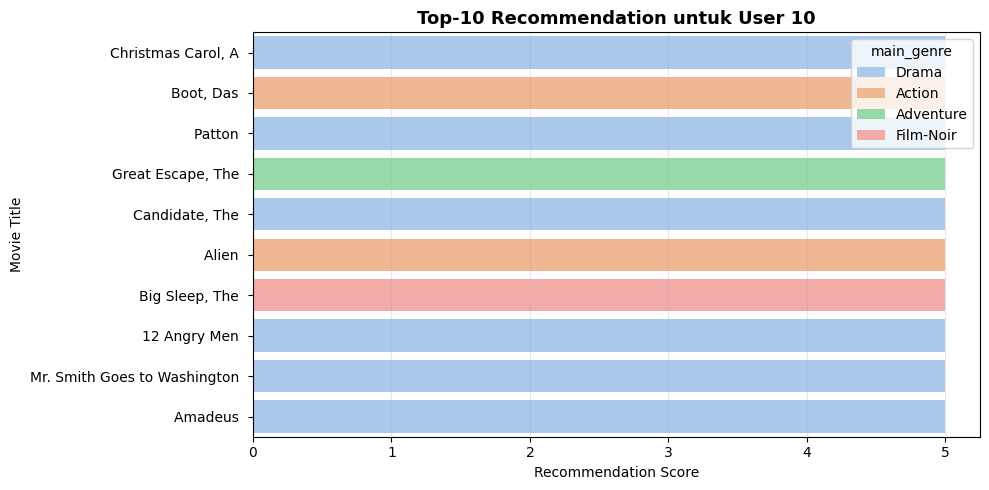

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=top10_rec,
    x='score',
    y='title',
    hue='main_genre',
    dodge=False,
    palette='pastel'
)

plt.title(
    f'Top-10 Recommendation untuk User {user_id}',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Recommendation Score')
plt.ylabel('Movie Title')

plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

Visualisasi menunjukkan daftar film dengan recommendation score tertinggi untuk pengguna target. Film dengan skor lebih tinggi menunjukkan bahwa film tersebut lebih banyak disukai oleh neighbor dengan similarity tinggi terhadap pengguna target.

# **Evaluasi Recommendation System**

Evaluasi dilakukan menggunakan Precision@K dan Recall@K untuk mengukur kualitas rekomendasi yang dihasilkan.

## **Precision@K**

Precision@K mengukur proporsi film rekomendasi yang benar-benar relevan bagi pengguna.

$$
Precision@K =
\frac{\text{Relevant Recommended Items}}
{K}
$$

## **Recall@K**

Recall@K mengukur kemampuan sistem menemukan film relevan dari seluruh film relevan yang dimiliki pengguna.

$$
Recall@K =
\frac{\text{Relevant Recommended Items}}
{\text{Relevant Items}}
$$

## **Fungsi Evaluasi**

In [ ]:
def precision_recall_at_k(
    user_id,
    recommended_items,
    test_df,
    k=10
):

    # Film relevan pada test set
    relevant_items = test_df[
        (test_df['user_id'] == user_id) &
        (test_df['rating'] >= 4)
    ]['item_id'].tolist()

    if len(relevant_items) == 0:
        return None, None

    recommended_k = recommended_items[:k]

    hit = len(
        set(recommended_k) &
        set(relevant_items)
    )

    precision = hit / k

    recall = hit / len(relevant_items)

    return precision, recall

## **Evaluasi Seluruh Threshold**

Evaluasi dilakukan pada seluruh threshold untuk mengetahui pengaruh struktur graph terhadap kualitas recommendation system.

In [ ]:
evaluation_results = []

for threshold, G in graphs.items():

    print(f"\nEvaluasi Threshold {threshold}")

    precision_scores = []
    recall_scores    = []

    eval_users = test_df['user_id'].unique()

    successful_users = 0

    for user_id in eval_users:

        rec_result = recommend_movies(
            user_id=user_id,
            G=G,
            ratings_df=train_df,
            similarity_df=similarity_df,
            movies_df=movies,
            top_n=10
        )

        if rec_result.empty:
            continue

        successful_users += 1

        recommended_items = rec_result[
            'item_id'
        ].tolist()

        precision, recall = precision_recall_at_k(
            user_id,
            recommended_items,
            test_df,
            k=10
        )

        if precision is not None:
            precision_scores.append(precision)

        if recall is not None:
            recall_scores.append(recall)

    avg_precision = np.mean(precision_scores)
    avg_recall    = np.mean(recall_scores)

    coverage = successful_users / len(eval_users)

    evaluation_results.append({
        'threshold'   : threshold,
        'precision@10': avg_precision,
        'recall@10'   : avg_recall,
        'coverage'    : coverage
    })

    print(f"Precision@10 : {avg_precision:.4f}")
    print(f"Recall@10    : {avg_recall:.4f}")
    print(f"Coverage     : {coverage:.4f}")

evaluation_df = pd.DataFrame(evaluation_results)

display(evaluation_df)


Evaluasi Threshold 0.15
Precision@10 : 0.0452
Recall@10    : 0.0550
Coverage     : 0.9894

Evaluasi Threshold 0.2
Precision@10 : 0.0877
Recall@10    : 0.1133
Coverage     : 0.8441

Evaluasi Threshold 0.25
Precision@10 : 0.1248
Recall@10    : 0.1985
Coverage     : 0.5536


,threshold,precision@10,recall@10,coverage
0,0.15,0.045179,0.055006,0.989396
1,0.20,0.087659,0.113311,0.844115
2,0.25,0.124805,0.198548,0.553552


Hasil evaluasi menunjukkan bahwa peningkatan threshold similarity mampu meningkatkan kualitas recommendation system. Pada threshold 0,15 diperoleh Precision@10 sebesar 0,0452 dan Recall@10 sebesar 0,0550 dengan coverage sangat tinggi yaitu 98,94%. Hal ini menunjukkan hampir seluruh pengguna memperoleh rekomendasi, namun kualitas rekomendasinya masih rendah karena graph terlalu padat sehingga neighbor yang digunakan mencakup pengguna dengan kemiripan preferensi yang kurang spesifik.

Pada threshold 0,20 performa recommendation system meningkat dengan Precision@10 sebesar 0,0877 dan Recall@10 sebesar 0,1133. Coverage masih cukup tinggi yaitu 84,41%, sehingga threshold ini memberikan keseimbangan yang baik antara kualitas rekomendasi dan jumlah pengguna yang terlayani.

Sementara itu, threshold 0,25 menghasilkan Precision@10 dan Recall@10 tertinggi yaitu 0,1248 dan 0,1985. Nilai Recall@10 yang mendekati 0,2 menunjukkan bahwa sistem mampu menemukan sekitar 20% film relevan dari keseluruhan film yang disukai pengguna. Namun coverage turun menjadi 55,36% karena banyak pengguna kehilangan neighbor dan menjadi isolated nodes.

Berdasarkan hasil tersebut, threshold 0,20 dipilih sebagai threshold optimal karena memberikan keseimbangan terbaik antara kualitas recommendation system dan coverage pengguna.

## **Visualisasi Precision@K dan Recall@K**

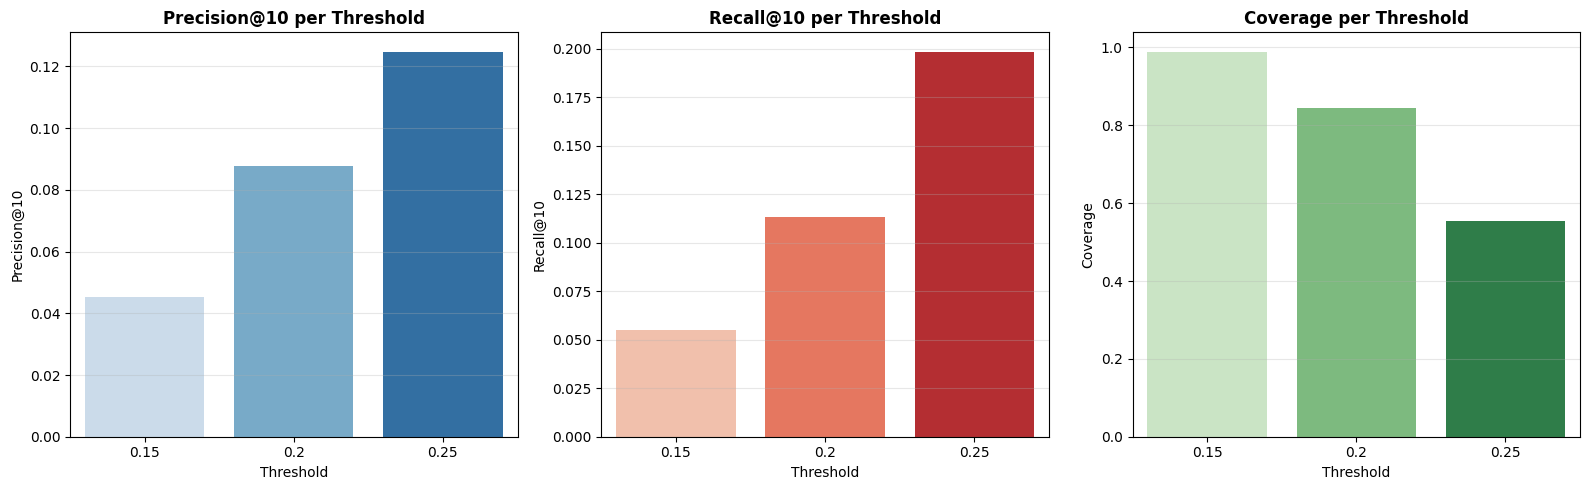

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))

# Precision
sns.barplot(
    data=evaluation_df,
    x='threshold',
    y='precision@10',
    palette='Blues',
    ax=axes[0]
)

axes[0].set_title(
    'Precision@10 per Threshold',
    fontsize=12,
    fontweight='bold'
)

axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Precision@10')

axes[0].grid(axis='y', alpha=0.3)

# Recall
sns.barplot(
    data=evaluation_df,
    x='threshold',
    y='recall@10',
    palette='Reds',
    ax=axes[1]
)

axes[1].set_title(
    'Recall@10 per Threshold',
    fontsize=12,
    fontweight='bold'
)

axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Recall@10')

axes[1].grid(axis='y', alpha=0.3)

# Coverage
sns.barplot(
    data=evaluation_df,
    x='threshold',
    y='coverage',
    palette='Greens',
    ax=axes[2]
)

axes[2].set_title(
    'Coverage per Threshold',
    fontsize=12,
    fontweight='bold'
)

axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('Coverage')

axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Visualisasi menunjukkan perbandingan performa recommendation system pada setiap threshold. Precision@10 menunjukkan tingkat relevansi rekomendasi yang dihasilkan, sedangkan Recall@10 menunjukkan kemampuan sistem menemukan film relevan pengguna.

## **Analisis Pengaruh Threshold terhadap Recommendation System**

Threshold similarity memiliki pengaruh langsung terhadap kualitas recommendation system dan coverage pengguna. Threshold rendah menghasilkan graph yang lebih padat sehingga hampir seluruh pengguna memiliki neighbor dan coverage menjadi tinggi. Namun, kualitas similarity antar pengguna cenderung lebih rendah sehingga rekomendasi kurang spesifik.

Sebaliknya, threshold tinggi menghasilkan hubungan similarity yang lebih kuat sehingga Precision@10 dan Recall@10 meningkat. Akan tetapi, jumlah neighbor menjadi lebih sedikit sehingga banyak pengguna kehilangan koneksi dan coverage recommendation system menurun.

Berdasarkan hasil evaluasi, threshold 0,20 menghasilkan keseimbangan terbaik antara kualitas recommendation system dan coverage pengguna sehingga dipilih sebagai threshold optimal.

## **Insight Recommendation System**

* Recommendation system berbasis graph berhasil memanfaatkan hubungan similarity antar pengguna untuk menghasilkan rekomendasi film yang relevan.
* Weighted recommendation score memungkinkan neighbor dengan similarity lebih tinggi memiliki pengaruh lebih besar terhadap rekomendasi.
* Filtering watched movies mencegah munculnya film yang sudah pernah ditonton pengguna.
* Threshold similarity memengaruhi kualitas recommendation system secara signifikan.
* Threshold rendah menghasilkan coverage tinggi tetapi kualitas rekomendasi lebih rendah.
* Threshold tinggi meningkatkan kualitas rekomendasi, namun menyebabkan banyak pengguna kehilangan neighbor sehingga coverage menurun.
* Threshold 0,20 memberikan keseimbangan terbaik antara Precision@10, Recall@10, dan coverage recommendation system.